# Identificação do problema de negócio:

### Problema de negócio:

Esse Projeto tem como objetivo desenvolver um sistema de identificação automática de operadores ineficientes para a empresa de telecomunicações CallMeMaybe, baseado em 3 critérios mensuráveis: Taxa de chamadas perdidas > 15%, tempo médio de espera > 46 segundos, e menos de 50 chamadas ativas por dia para operadores de saída

### Link do arquivo para acessar o PDF da Apresentação e o Dashboard no Tableau Public:

Link: [Clique aqui para acessar o arquivo ZIP no Google Drive](https://drive.google.com/file/d/1K1nJXoxC5y6uG-h48ADkIbp9nOoh2L1I/view?usp=sharing)

##### Instruções para acessar os materiais:

Ao acessar esse link, você será direcionado ao Google Drive, onde baixará um arquivo zip com o PDF da apresentação e uma pasta com o link para o Dashboard em um arquivo `dashboard.txt` e o arquivo CSV usado no Tableau para gerar o Dashboard. A estrutura será a seguinte:

------ Arquivo ZIP ------

  > * apresentacao.pdf
  
  > __ pasta dashboard
  
  >> * arquivo.csv
  
  >> * dashboard.txt

### Descrição dos dados:

- O dataset **`telecom_dataset_us.csv`** contém as informações gerais das chamadas. Ele possui as seguintes colunas:

| Campo | Descrição | Tipo de Dado | Amostra | Valores Ausentes | Deveria ser do Tipo |
|-------|-----------| ------- | ------- | ------- | ------- |
| **`user_id`** | ID da conta do cliente | int64 | 166377 | 0 | - |
| **`date`** | Data em que as estatísticas foram coletadas | Object | '2019-08-04 00:00:00+03:00' | 0 | datetime |
| **`direction`** | "Direção" da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**) | Object | 'in' / 'out' | 0 | category |
| **`internal`** | Indica se a chamada foi **interna** (entre operadores de um mesmo cliente) | Object | 'True' / 'False'| 117 | boolean |
| **`operator_id`** | Identificador do operador | float64 | 880022.0 | 8172 | int64 |
| **`is_missed_call`** | Indica se foi uma **chamada perdida** (True para perdida e False para atendida) | boolean | False / True | 0 | - |
| **`calls_count`** | Número de chamadas | int64 | 2 | 0 | - |
| **`call_duration`** | Duração da chamada em segundos (sem incluir o tempo de espera) | int64 | 10 | 0 | - |
| **`total_call_duration`** | Duração total da chamada (incluindo o tempo de espera) | int64 | 4 | 0 | - |

<br>

- O dataset **`telecom_clients_us.csv`** contém informações sobre os clientes. Ele possui as seguintes colunas:

| Campo | Descrição | Tipo de Dado | Amostra | Valores Ausentes | Deveria ser do Tipo |
|-------|-----------| ------- | ------- | ------- | ------- |
| **`user_id`** | ID do cliente | int64 | 166713 | 0 | - |
| **`tariff_plan`** | Plano tarifário atual do cliente | object | 'A' / 'B' / 'C' | 0 | category | 
| **`date_start`** | Data de registro do cliente | object | '2019-08-23' | 0 | datetime |

<br> 

### Indicadores chave (principais KPIs usadas):

Vamos usar os seguintes indicadores de negócio (KPIs):

- **KPI 1: Taxa de Chamadas Perdidas**
  
Fórmula:

Taxa de Chamadas Perdidas = (Número de Chamadas Perdidas / Total de Chamadas Recebidas) × 100

- **KPI 2: Tempo Médio de Espera**
  
Fórmula:

Tempo Médio de Espera = Σ(Tempo de Espera de cada Chamada) / Número Total de Chamadas

- **KPI 3: Volume de Chamadas Ativas (Operadores de Saída)**
  
Fórmula:

Chamadas Ativas por Dia = Número de Chamadas Realizadas pelo Operador / Número de Dias Trabalhados

- **KPI 4: Produtividade Geral**

Temos 3 critérios com limiares definidos para cada operador:

Taxa de chamadas perdidas > 15%

Tempo médio de espera > 46 segundos

Chamadas ativas por dia < 50 (apenas operadores de saída)

A KPI 4 consiste em criar um Score de Ineficiência por operador, onde cada critério violado soma 1 ponto:

| Score	| Classificação |
|-------|---------------|
|   0 ou 1	|✅ Eficiente  |
|   2 ou 3	|🔴 Ineficiente  |	

# Bibliotecas e Funções utilizadas

## Bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from scipy import stats as st

## Funções

### - Função **teste_dados_continuos**: Faz um teste de hipóteses entre a igualdade das médias de duas variáveis contínuas

In [3]:
def teste_dados_continuos(metrica_A, metrica_B, h_0: str, h_1: str, significancia: float = 0.05):
    '''
    Analisa normalidade (Shapiro ou Anderson-Darling), homogeneidade de variância (Levene) e decide entre:
    - T-test (Student ou Welch) se normal.
    - Mann-Whitney se não normal.

    OBS: Usa Shapiro-Wilk para N < 5000 e Anderson-Darling para N >= 5000.

     INPUTS:
    metrica_A: Métrica contínua usada no grupo A (Ex.: Média, Valor bruto, Valor acumulado, etc...) -> Serie or List
    metrica_B: Métrica contínua usada no grupo B (Ex.: Média, Valor bruto, Valor acumulado, etc...) -> Serie or List
    h_0: Hipótese nula -> 'str'
    h_1: Hipótese alternativa -> 'str'
    significancia: Nivel de significancia estatistica usado - entre 0 e 1 (Definido 0.05 como padrão) -> 'float'
    '''
    
    # 1. Limpeza e Preparação (Garante que sejam Series para usar dropna)
    a = pd.Series(metrica_A).dropna()
    b = pd.Series(metrica_B).dropna()
    
    def checar_normalidade(dados, nome_grupo):
        n = len(dados)
        if n < 5000:
            stat, p = st.shapiro(dados)
            is_normal = p > significancia
            print(f"Shapiro-Wilk ({nome_grupo}): p={p:.5f} | Normal: {is_normal}")
            return is_normal
        else:
            # Anderson-Darling retorna estatística e valores críticos
            res = st.anderson(dados, dist='norm')
            # res.critical_values[2] corresponde ao nível de 5% (0.05)
            # Se a estatística for MENOR que o valor crítico, não rejeitamos a normalidade
            is_normal = res.statistic < res.critical_values[2] 
            print(f"Anderson-Darling ({nome_grupo}): Stat={res.statistic:.3f}, Crit(5%)={res.critical_values[2]} | Normal: {is_normal}")
            return is_normal

    normal_A = checar_normalidade(a, "Grupo A")
    normal_B = checar_normalidade(b, "Grupo B")

    # 2. Decide qual teste usar baseado na Normalidade E Variância
    if normal_A and normal_B:
        # DADOS NORMAIS -> Verificar Variância (Levene)
        levene_stat, p_levene = st.levene(a, b)
        variancias_iguais = p_levene > significancia
        
        print(f"Variância (Levene): p={p_levene:.5f} (Iguais: {variancias_iguais})")
        
        # Executa Teste t (Student se var iguais, Welch se diferentes)
        t_stat, p_value = st.ttest_ind(a, b, equal_var=variancias_iguais)
        tipo_teste = "Teste t de Student" if variancias_iguais else "Teste t de Welch"
    else:
        # DADOS NÃO NORMAIS -> Mann-Whitney
        u_stat, p_value = st.mannwhitneyu(a, b, alternative='two-sided')
        tipo_teste = "Mann-Whitney"

    print(f"Decisão: Usando {tipo_teste}")

    # 3. Resultado Final
    print("\n--- Resultado do Teste de Hipótese ---")
    print(f"P-valor: {p_value:.4f} | Alpha: {significancia}")
    
    if p_value < significancia:
        resultado = f"❌ Rejeitamos H0: {h_1}"
    else: 
        resultado = f"✅ Mantemos H0: {h_0}"
    
    print(resultado)

# 1. Carregamento, Limpeza e Processamento de Dados

## 1.1. Carregando os dados das tabelas `telecom_dataset_us.csv` e `telecom_clients_us.csv`:

### 1.1.1. Otimizando os dados com uma amostra, para o carregamento dos dados completos:

- **Carregando uma amostra dos dados e suas informações gerais:**

➔ ***Amostra do dataframe `telecom_dataset_us.csv`:***

In [4]:
dataset_amostra = pd.read_csv('../datasets/telecom_dataset_us.csv', nrows=100)

print(dataset_amostra.info(memory_usage='deep'))

dataset_amostra.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              100 non-null    int64  
 1   date                 100 non-null    object 
 2   direction            100 non-null    object 
 3   internal             100 non-null    bool   
 4   operator_id          88 non-null     float64
 5   is_missed_call       100 non-null    bool   
 6   calls_count          100 non-null    int64  
 7   call_duration        100 non-null    int64  
 8   total_call_duration  100 non-null    int64  
dtypes: bool(2), float64(1), int64(4), object(2)
memory usage: 16.5 KB
None


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1


No dataframe `dataset_amostra`, precisamos converter os tipos de dados das seguintes colunas:

`date` ➔ para **datetime** 

`direction` ➔ para **category** 

`internal` ➔ para **boolean** 

➔ ***Amostra do dataframe `telecom_clients_us.csv`:***

In [5]:
clients_amostra = pd.read_csv('../datasets/telecom_clients_us.csv', nrows=100)

print(clients_amostra.info(memory_usage='deep'))

clients_amostra.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      100 non-null    int64 
 1   tariff_plan  100 non-null    object
 2   date_start   100 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.6 KB
None


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29


No dataframe `clients_amostra`, precisamos converter os tipos de dados das seguintes colunas:

`tariff_plan` ➔ para **category**

`date_start` ➔ para **datetime**  

- **Otimizando as amostras carregadas:**

➔ **`dataset_amostra`:**

In [9]:
dataset_amostra['date'] = pd.to_datetime(dataset_amostra['date'], format='ISO8601', errors='coerce')
dataset_amostra['direction'] = dataset_amostra['direction'].astype('category')
dataset_amostra['internal'] = dataset_amostra['internal'].astype('boolean')
dataset_amostra['direction'] = dataset_amostra['direction'].astype('category')
dataset_amostra['internal'] = dataset_amostra['internal'].astype('boolean')

In [10]:
dataset_amostra.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              100 non-null    int64                    
 1   date                 100 non-null    datetime64[ns, UTC+03:00]
 2   direction            100 non-null    category                 
 3   internal             100 non-null    boolean                  
 4   operator_id          88 non-null     float64                  
 5   is_missed_call       100 non-null    bool                     
 6   calls_count          100 non-null    int64                    
 7   call_duration        100 non-null    int64                    
 8   total_call_duration  100 non-null    int64                    
dtypes: bool(1), boolean(1), category(1), datetime64[ns, UTC+03:00](1), float64(1), int64(4)
memory usage: 5.4 KB


➔ **`clients_amostra`:**

In [11]:
clients_amostra['date_start'] = pd.to_datetime(clients_amostra['date_start'], format="%Y-%m-%d")
clients_amostra['tariff_plan'] = clients_amostra['tariff_plan'].astype('category')

In [12]:
clients_amostra.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      100 non-null    int64         
 1   tariff_plan  100 non-null    category      
 2   date_start   100 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 2.0 KB


conclusão: 

Conseguimos otimizar a memória usada de **18.1kb** para **5.4kb** em nosso dataframe `dataset_amostra`, e de **13.1kb** para **2.0kb** em nosso dataframe `clients_amostra`, o que é uma melhoria excelente. Vamos usar essas conversões de dados para carregar os nossos dataframes completos, usando os parâmetros `parse_dates` e `dtype` do método read_csv( ).

### 1.1.2. Carregando os dados completos:

In [13]:
dataset = pd.read_csv('../datasets/telecom_dataset_us.csv', parse_dates=['date'], dtype={'direction':'category', 'internal':'boolean'})

clients = pd.read_csv('../datasets/telecom_clients_us.csv', parse_dates=['date_start'], dtype={'tariff_plan':'category'})

## 1.2. Imprimindo as informações gerais e as primeiras linhas de cada tabela:

- Dataframe **`dataset`:**

In [14]:
dataset.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[ns, UTC+03:00]
 2   direction            53902 non-null  category                 
 3   internal             53785 non-null  boolean                  
 4   operator_id          45730 non-null  float64                  
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: bool(1), boolean(1), category(1), datetime64[ns, UTC+03:00](1), float64(1), int64(4)
memory usage: 2.7 MB


In [15]:
dataset.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


- Dataframe **`clients`:**

In [16]:
clients.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    category      
 2   date_start   732 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 12.5 KB


In [17]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## 1.3. Verificando a qualidade dos dados:

### 1.3.1. Valores ausentes:

In [18]:
dataset.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [19]:
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

Não temos valores ausentes no dataframe `cliests`, enquanto o dataframe `dataset` apresenta valores ausentes nas colunas `internal` e `operator_id`. Vamos decidir o que fazer com eles: 

In [20]:
nulos_operator = (100 * dataset['operator_id'].isna().sum() / dataset.shape[0]).round(2)
nulos_internal = (100 * dataset['internal'].isna().sum() / dataset.shape[0]).round(2)

print(f'Verificamos que {nulos_operator}% dos valores da coluna "operator_id" são ausentes. \n')
print(f'Verificamos que {nulos_internal}% dos valores da coluna "internal" são ausentes.')

Verificamos que 15.16% dos valores da coluna "operator_id" são ausentes. 

Verificamos que 0.22% dos valores da coluna "internal" são ausentes.


Vimos que 0.22% dos valores da coluna `internal` são ausentes. Como são pouquíssimos valores ausentes, a perda de dados será mínima e não afetará a análise ao remove-los:

In [21]:
dataset = dataset.dropna(subset=['internal'])

Vimos que 15.16% dos valores da coluna `operator_id` são ausentes. Como o objetivo do projeto é identificar operadores ineficientes, precisamos que cada linha tenha um operator_id para conseguirmos avaliar o desempenho de cada operador. Sem esse ID, a linha não contribui para a análise, então devemos remover os valores ausentes desta coluna:

In [22]:
dataset = dataset.dropna(subset=['operator_id'])

### 1.3.2. Problemas de duplicados:

- ***Duplicados expliscitos:***

→ Tabela `dataset`:

In [23]:
dataset.duplicated().sum()

np.int64(4179)

Esses duplicados certamente estarão inflando a nossa análise e KPIs para cada chamada duplicada. Esses duplicados provavelmente representam um erro no sistema de coleta de dados — o mesmo registro foi gravado mais de uma vez. Diante disso, devemos remove-los:

In [24]:
dataset = dataset.drop_duplicates()

→ Tabela `clients`:

In [25]:
clients.duplicated().sum()

np.int64(0)

Boas notícias: Sem duplicados expliscitos na tabela `clients`

## 1.4. Criando novas variáveis e colunas para o nosso conjunto de dados:

In [26]:
# criando uma coluna para calcular o tempo de espera de cada atendimento (linha da tabela):
dataset['espera'] = dataset['total_call_duration'] - dataset['call_duration']

# Criando uma coluna dia com apenas a data (Ex. "2026-01-02"):
dataset['dia'] = dataset['date'].dt.date
dataset.head(3)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,espera,dia
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5,2019-08-05
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1,2019-08-05
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8,2019-08-05


## 1.5. Tratando outros erros de dados:

In [27]:
# observando a distribuição da coluna espera:
dataset['espera'].describe()

count    41491.000000
mean       312.213227
std       1176.102940
min          0.000000
25%         19.000000
50%         60.000000
75%        219.000000
max      46474.000000
Name: espera, dtype: float64

Trata-se de uma distribuição de calda longa (não Normal): Desvio padrão gigantesco frente à média.

Para uma análise analítica robusta sobre a eficiência real de um call center, vale a pena tratarmos chamadas com tempo de espera ou duração abaixo de um threshold mínimo (aqui vamos usar < 3  segundos) com a sua mediana, sob certas circunstâncias, tratando-as como erros de sistema ou desistências, e não como atendimentos eficientes. Mas ao mesmo tempo, não perdendo os dados das outras colunas nessas linhas problemáticas.

Se mantermos esses "operadores de 2 segundos" na base principal de análise de desempenho, a média global vai parecer melhor do que a realidade da operação (viés otimista).

Eles vão esticar a cauda inferior do gráfico, distorcendo a escala visual da distribuição real.

Esses erros podem está associados aos seguintes problemas:

- Pode ser uma chamada atendida (is_missed_call=False) de entrada (in): o tempo de espera seria o tempo que o cliente ficou aguardando o operador atender. 2 segundos seria anormal. Devemos substituir esse tempo de espera pela mediana

In [28]:
# Trocando os tempos de esopera problemáticos pela mediana dos tempos de espera:

mediana = dataset['espera'].median()
mask = (dataset['espera'] < 3) & (dataset['direction'] == 'in') & (dataset['is_missed_call'] == False)
dataset.loc[mask, "espera"] = mediana

dataset[mask].sample(3)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,espera,dia
49500,168187,2019-11-26 00:00:00+03:00,in,True,937962.0,False,1,3,4,60,2019-11-26
36003,167575,2019-10-28 00:00:00+03:00,in,False,926872.0,False,4,231,233,60,2019-10-28
49164,168187,2019-11-21 00:00:00+03:00,in,True,937962.0,False,1,7,7,60,2019-11-21


Outros fatores que podem inflacionar nossa análise são chamadas não atendidas com alto tempo de espera: Vamos substituir o tempo de espera de chamadas não atendidas com tempo de espera acima da mediana dos tempos de espera, pela mediana dos tempos de espera.

In [29]:
mask = (dataset['espera'] > mediana) & (dataset['is_missed_call'] == True)
dataset.loc[mask,'espera'] = mediana

# 2. Análise Exploratória de Dados (EDA)

In [30]:
calls = dataset.merge(clients, on='user_id')
calls.head(3)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,espera,dia,tariff_plan,date_start
0,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5,2019-08-05,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1,2019-08-05,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8,2019-08-05,B,2019-08-01


In [31]:
maximo = calls.groupby('operator_id')['tariff_plan'].nunique().max()

print(f'Cada operador atende clientes de no máximo {maximo} planos diferentes')

Cada operador atende clientes de no máximo 1 planos diferentes


Acabamos de confirmar que cada operador é responsável por atender clientes de um único plano. Isso nos permitirá segmentar a nossa análise por plano, já que o plano passa a ser uma característica unívoca do operador.

## 2.1. Analisando a distribuição das taxas de chamadas perdidas dos operadores por plano.

**Fórmula:**

***Taxa de Chamadas Perdidas = (Número de Chamadas Perdidas / Total de Chamadas Recebidas) × 100***

In [32]:
# Calculando a taxa de chamadas perdidas de cada operador por plano

# chamadas perdidas do operador
mask = calls['is_missed_call'] == True

chamadas_perdidas = calls[mask].groupby(['operator_id', 'tariff_plan']).agg({
                                                        'calls_count':'sum'
                                                        }).reset_index().rename(columns={'calls_count':'perdidas'})

# todas as chamadas do operador
chamadas = calls.groupby(['operator_id', 'tariff_plan']).agg({
                                                        'calls_count':'sum'
                                                        }).reset_index()

# juntando as informações
chamadas_perdidas = chamadas_perdidas.merge(chamadas, on=['operator_id','tariff_plan'])

chamadas_perdidas['chamadas_perdidas_percent'] = (100 * chamadas_perdidas['perdidas'] / chamadas_perdidas['calls_count']).round(2)

chamadas_perdidas = chamadas_perdidas[['operator_id','tariff_plan','chamadas_perdidas_percent']]

chamadas_perdidas = chamadas_perdidas.dropna() # Como cada operador atende clientes de um único plano, podemos remover esses valores ausentes

chamadas_perdidas.head()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\4178461393.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chamadas_perdidas = calls[mask].groupby(['operator_id', 'tariff_plan']).agg({
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\4178461393.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chamadas = calls.groupby(['operator_id', 'tariff_plan']).agg({


,operator_id,tariff_plan,chamadas_perdidas_percent
1,879896.0,B,26.99
4,879898.0,B,32.28
7,880020.0,B,48.89
10,880022.0,B,53.30
13,880026.0,B,29.03


- Afim de termos uma distribuição de dados e um teste de hipóteses mais fiél, vamos remover os outlaiers da coluna `chamadas_perdidas_percent` para cada plano.

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\909624982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


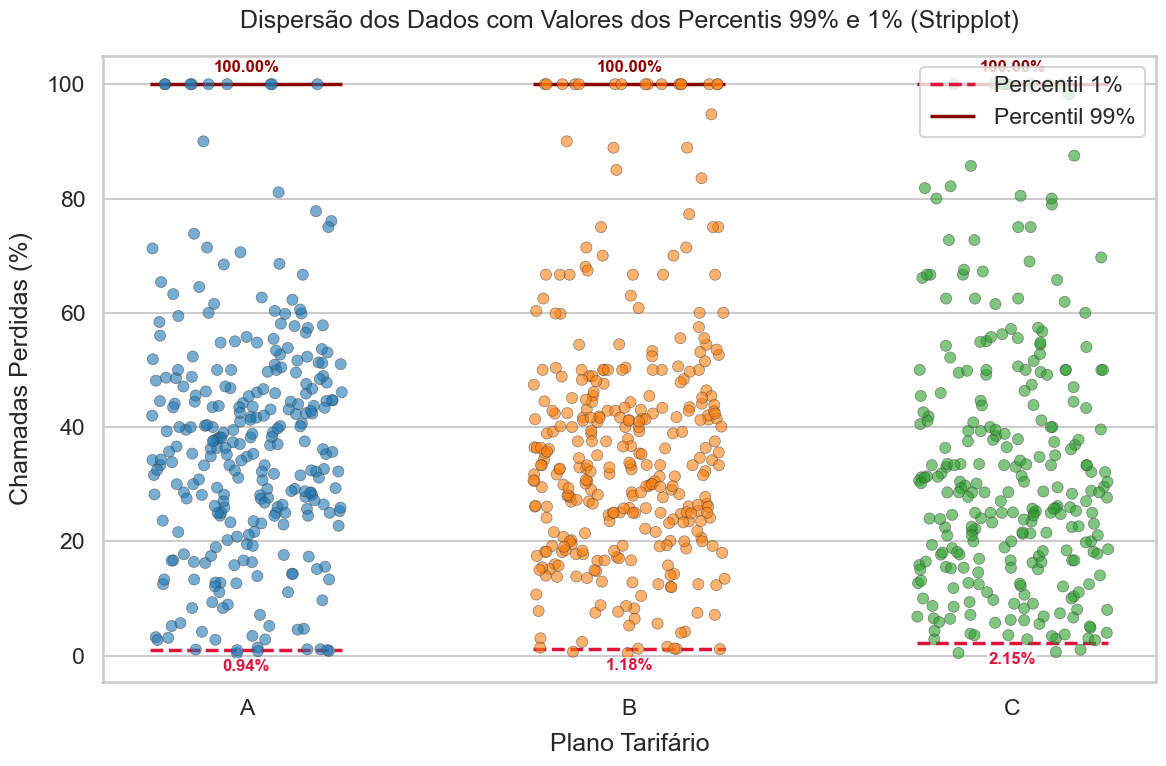

In [33]:
# Vamos visualizar os outlaiers e limpa-los para termos uma distribuição mais fiel:

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(12, 8))


sns.stripplot(
    data=chamadas_perdidas,
    x="tariff_plan",
    y="chamadas_perdidas_percent",
    ax=ax,
    palette="tab10",
    jitter=0.25,
    size=8,
    alpha=0.6,
    linewidth=0.5,
)

order = [t.get_text() for t in ax.get_xticklabels()]
if not order:
    order = sorted(chamadas_perdidas["tariff_plan"].unique())

label_p1_added = False
label_p99_added = False

for i, plan in enumerate(order):
    sub_data = chamadas_perdidas[chamadas_perdidas["tariff_plan"] == plan][
        "chamadas_perdidas_percent"
    ].dropna()

    if not sub_data.empty:
        p1 = np.percentile(sub_data, 1)
        p99 = np.percentile(sub_data, 99)

        offset = 0.25
        xmin = i - offset
        xmax = i + offset

        ax.hlines(
            y=p1,
            xmin=xmin,
            xmax=xmax,
            colors="crimson",
            linestyles="--",
            linewidth=2.5,
            label="Percentil 1%" if not label_p1_added else "",
        )
        label_p1_added = True

        ax.text(
            x=i,
            y=p1 - (ax.get_ylim()[1] * 0.015),
            s=f"{p1:.2f}%",
            color="crimson",
            ha="center",
            va="top",
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
        )

        ax.hlines(
            y=p99,
            xmin=xmin,
            xmax=xmax,
            colors="darkred",
            linestyles="-",
            linewidth=2.5,
            label="Percentil 99%" if not label_p99_added else "",
        )
        label_p99_added = True

        ax.text(
            x=i,
            y=p99 + (ax.get_ylim()[1] * 0.015),
            s=f"{p99:.2f}%",
            color="darkred",
            ha="center",
            va="bottom",
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
        )

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles=handles, labels=labels, loc="upper right")

ax.set_title("Dispersão dos Dados com Valores dos Percentis 99% e 1% (Stripplot)", pad=20)
ax.set_xlabel("Plano Tarifário", labelpad=10)
ax.set_ylabel("Chamadas Perdidas (%)", labelpad=10)

plt.tight_layout()
plt.show()

- Vamos considerar outliers os valores que escapam da faixa dos percentis 1% e 99% em cada plano. Vamos descarta-los do nosso conjunto de dados:

In [34]:
percentis = {} # Criando um dicionário vazio onde a chave será o plano e os valores será a lista [p1, p99] de cada plano

for i, plan in enumerate(order):
    sub_data = chamadas_perdidas[chamadas_perdidas["tariff_plan"] == plan][
        "chamadas_perdidas_percent"
    ].dropna()

    if not sub_data.empty:
        p1 = np.percentile(sub_data, 1)
        p99 = np.percentile(sub_data, 99)
        percentis[plan] = [p1, p99]

percentis

{'A': [np.float64(0.9434), np.float64(100.0)],
 'B': [np.float64(1.1824999999999999), np.float64(100.0)],
 'C': [np.float64(2.1522), np.float64(100.0)]}

In [35]:
# limpando os outlaiers em cada plano:
for plan, value in percentis.items():
    filtro = chamadas_perdidas[chamadas_perdidas["tariff_plan"] == plan]
    mask = (filtro["chamadas_perdidas_percent"] > value[0]) & (filtro["chamadas_perdidas_percent"] < value[1])
    chamadas_perdidas[chamadas_perdidas["tariff_plan"] == plan] = filtro[mask]

- Por fim, vamos visualizar a distribuição dos dados limpos:

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\1589097961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\1589097961.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


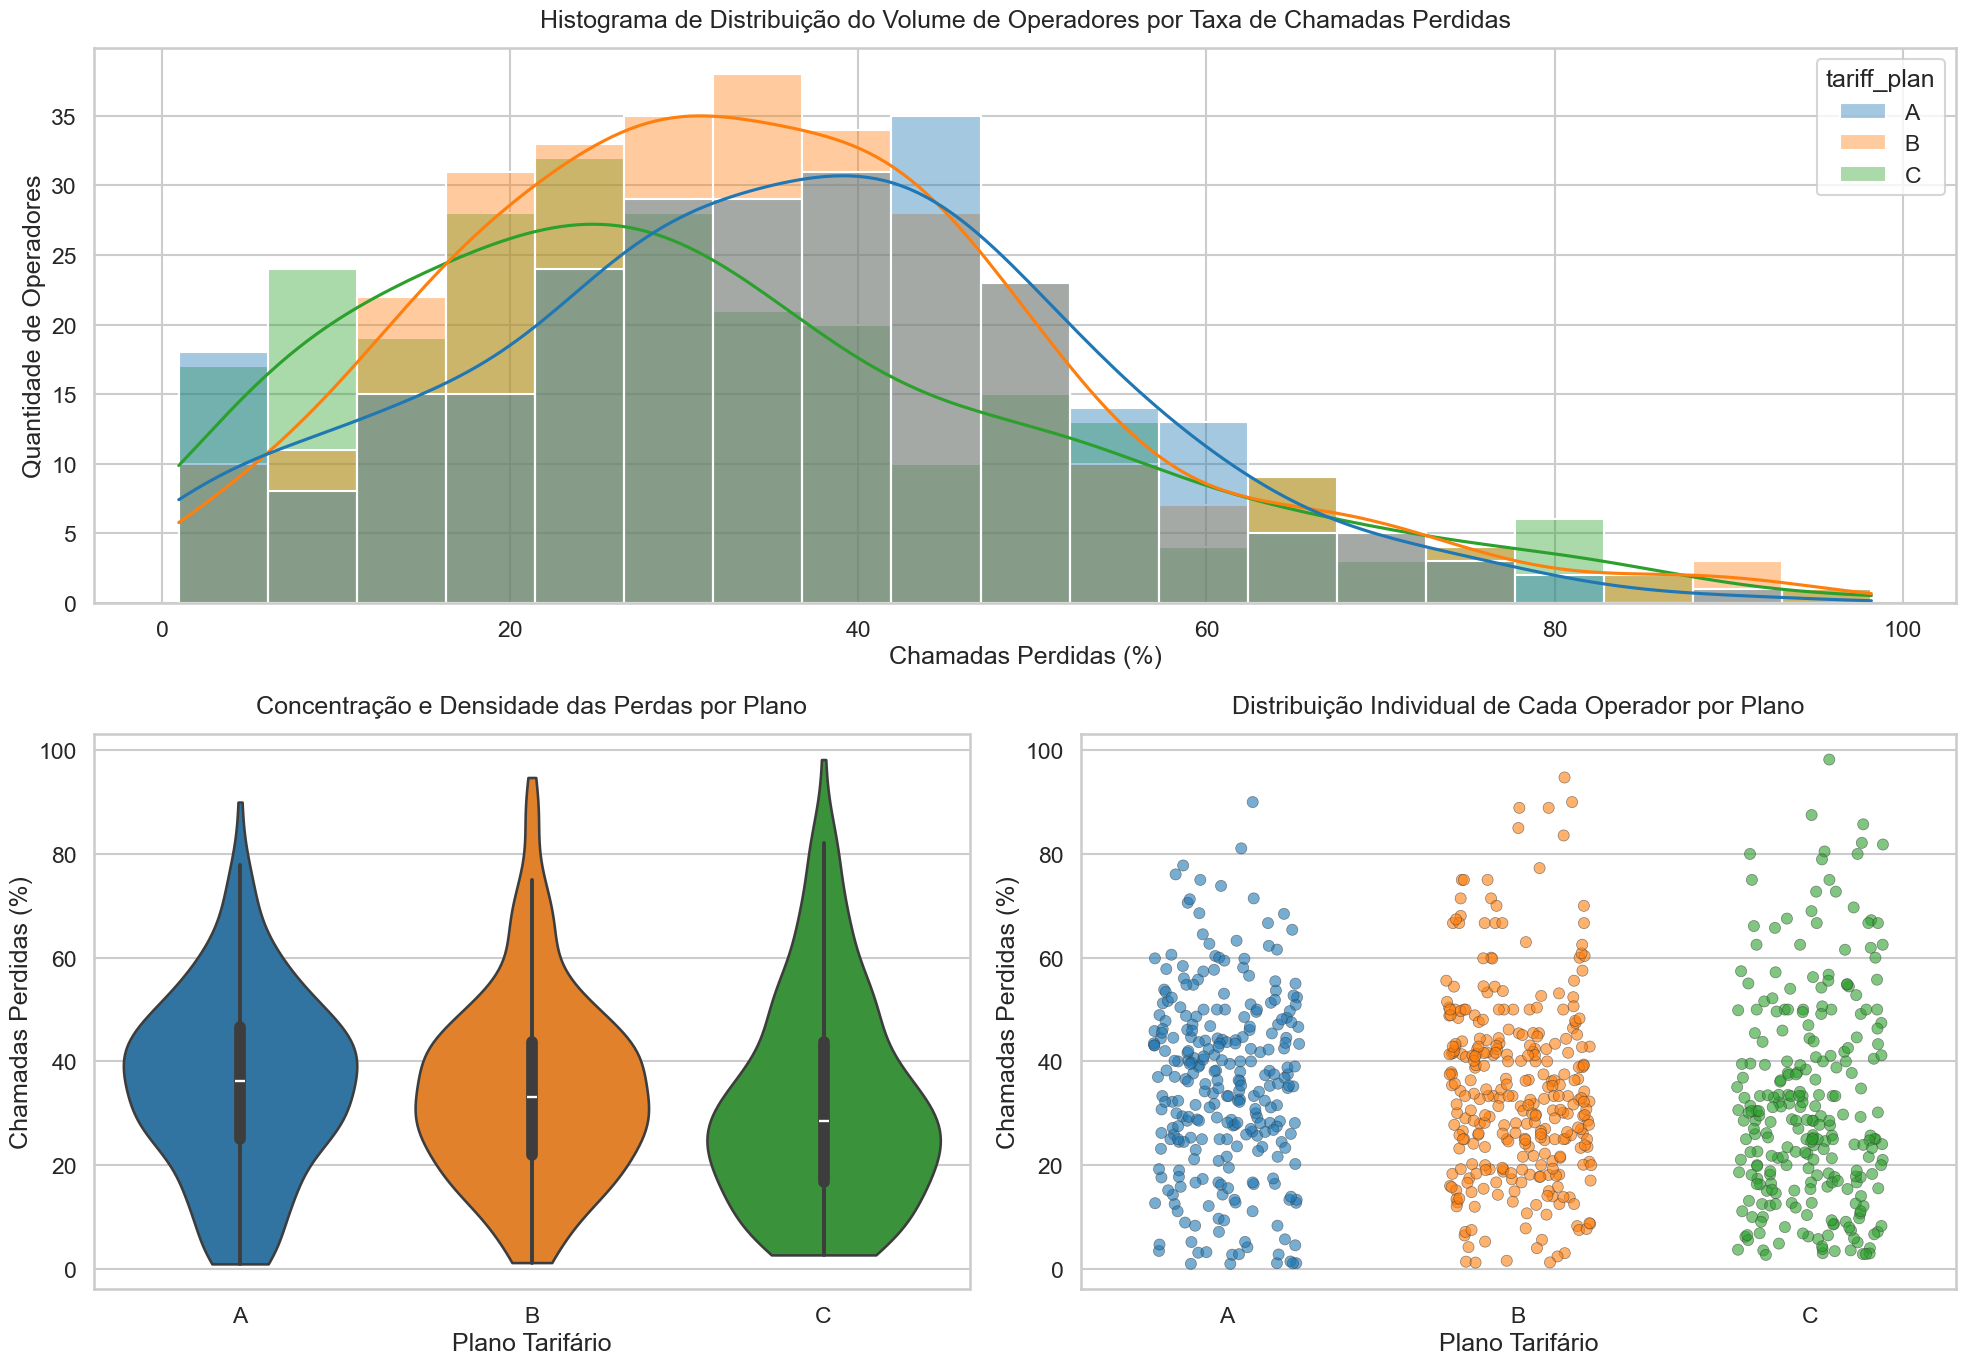

In [36]:
chamadas_perdidas = chamadas_perdidas.dropna()

sns.set_theme(style="whitegrid", context="talk")

mosaic = [["Hist", "Hist"], ["Violin", "Strip"]]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(20, 14))

sns.histplot(
    data=chamadas_perdidas,
    x="chamadas_perdidas_percent",
    hue="tariff_plan",
    stat="count",
    multiple="layer",
    element="bars",
    kde=True,
    alpha=0.4,
    ax=axes["Hist"],
    palette="tab10",
)
axes["Hist"].set_title("Histograma de Distribuição do Volume de Operadores por Taxa de Chamadas Perdidas", pad=15)
axes["Hist"].set_xlabel("Chamadas Perdidas (%)")
axes["Hist"].set_ylabel("Quantidade de Operadores")

sns.violinplot(
    data=chamadas_perdidas,
    x="tariff_plan",
    y="chamadas_perdidas_percent",
    ax=axes["Violin"],
    palette="tab10",
    inner="box",
    cut=0,
)
axes["Violin"].set_title("Concentração e Densidade das Perdas por Plano", pad=15)
axes["Violin"].set_xlabel("Plano Tarifário")
axes["Violin"].set_ylabel("Chamadas Perdidas (%)")

sns.stripplot(
    data=chamadas_perdidas,
    x="tariff_plan",
    y="chamadas_perdidas_percent",
    ax=axes["Strip"],
    palette="tab10",
    jitter=0.25,
    size=8,
    alpha=0.6,
    linewidth=0.5,
)
axes["Strip"].set_title("Distribuição Individual de Cada Operador por Plano", pad=15)
axes["Strip"].set_xlabel("Plano Tarifário")
axes["Strip"].set_ylabel("Chamadas Perdidas (%)")

plt.tight_layout()
plt.show()

In [37]:
chamadas_perdidas.groupby('tariff_plan')['chamadas_perdidas_percent'].agg(['min','median','mean','std','max']).T

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\188490020.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chamadas_perdidas.groupby('tariff_plan')['chamadas_perdidas_percent'].agg(['min','median','mean','std','max']).T


tariff_plan,A,B,C
min,0.97000,1.220000,2.700000
median,36.29000,33.140000,28.570000
mean,35.59163,34.644444,31.798945
std,17.50387,17.717576,20.140072
max,90.00000,94.740000,98.200000


conclusão: 

- Operadores que atendem clientes do plano C são mais eficientes para o requisito taxa de chamadas perdidas, pois possuem uma distribuição mais concentrada em uma região de baixa taxa de chamadas perdidas, onde a mediana e média são as menores dentre os 3 planos.

## 2.2. Analisando a distribuição do tempo médio de espera de cada operador por plano.

**Fórmula:**

***Tempo Médio de Espera = Σ(Tempo de Espera de cada Chamada) / Número Total de Chamadas***

- Para a análise do tempo de espera, devemos considerar apenas as chamadas atendidas (para termos uma distribuição real do tempo de eficiência dos operadores)

In [38]:
# Calculando o tempo médio de espera de cada operador por plano:
# temos que dividir o tempo de espera total pelo número de chamadas total de cada operador
filtro = calls[calls['is_missed_call'] == False ]
espera = filtro.groupby(['operator_id','tariff_plan']).agg({
                                                          'espera':'sum',
                                                          'calls_count':'sum'
                                                          }).reset_index()

espera['espera_media'] = espera['espera'] / espera['calls_count']

espera = espera[['operator_id','tariff_plan','espera_media']]

espera = espera.dropna() # pois cada operador atende clientes de um único plano

espera.head()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\103149737.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  espera = filtro.groupby(['operator_id','tariff_plan']).agg({


,operator_id,tariff_plan,espera_media
1,879896.0,B,9.628866
4,879898.0,B,10.936187
7,880020.0,B,6.260870
10,880022.0,B,7.260870
13,880026.0,B,6.340278


- Analisando os outliers da coluna `espera_media` por plano:

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\918446213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


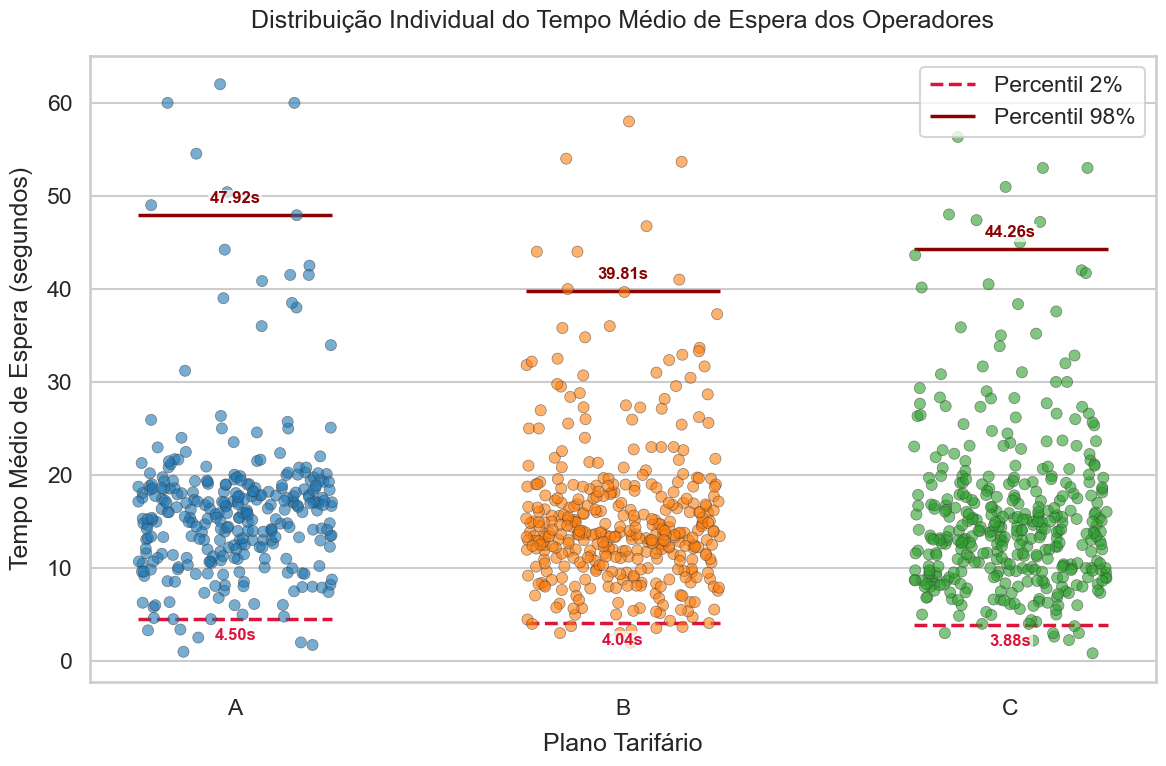

In [39]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(12, 8))

sns.stripplot(
    data=espera,
    x="tariff_plan",
    y="espera_media",
    ax=ax,
    palette="tab10",
    jitter=0.25,
    size=8,
    alpha=0.6,
    linewidth=0.5,
)

order = [t.get_text() for t in ax.get_xticklabels()]
if not order:
    order = sorted(espera["tariff_plan"].unique())

label_p2_added = False
label_p98_added = False

for i, plan in enumerate(order):
    sub_data = espera[espera["tariff_plan"] == plan]["espera_media"].dropna()

    if not sub_data.empty:
        p2 = np.percentile(sub_data, 2)
        p98 = np.percentile(sub_data, 98)

        offset = 0.25
        xmin = i - offset
        xmax = i + offset

        ax.hlines(
            y=p2,
            xmin=xmin,
            xmax=xmax,
            colors="crimson",
            linestyles="--",
            linewidth=2.5,
            label="Percentil 2%" if not label_p2_added else "",
        )
        label_p2_added = True

        ax.text(
            x=i,
            y=p2 - (ax.get_ylim()[1] * 0.015),
            s=f"{p2:.2f}s",
            color="crimson",
            ha="center",
            va="top",
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
        )

        ax.hlines(
            y=p98,
            xmin=xmin,
            xmax=xmax,
            colors="darkred",
            linestyles="-",
            linewidth=2.5,
            label="Percentil 98%" if not label_p98_added else "",
        )
        label_p98_added = True

        ax.text(
            x=i,
            y=p98 + (ax.get_ylim()[1] * 0.015),
            s=f"{p98:.2f}s",
            color="darkred",
            ha="center",
            va="bottom",
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
        )

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles=handles, labels=labels, loc="upper right")

ax.set_title(
    "Distribuição Individual do Tempo Médio de Espera dos Operadores", pad=20
)
ax.set_xlabel("Plano Tarifário", labelpad=10)
ax.set_ylabel("Tempo Médio de Espera (segundos)", labelpad=10)

plt.tight_layout()
plt.show()

Vamos considerar outliers os valores que escapam da faixa dos percentis 2% e 98% em cada plano. Vamos descarta-los do nosso conjunto de dados.

- Limpando os outliers:

In [40]:
percentis = {} # Criando um dicionário vazio onde a chave será o plano e os valores será a lista [p2, p98] de cada plano

for i, plan in enumerate(order):
    sub_data = espera[espera["tariff_plan"] == plan]["espera_media"]

    if not sub_data.empty:
        p2 = np.percentile(sub_data, 2)
        p98 = np.percentile(sub_data, 98)
        percentis[plan] = [p2, p98]

percentis

{'A': [np.float64(4.499264345267288), np.float64(47.92307692307692)],
 'B': [np.float64(4.044017467248908), np.float64(39.805476190476185)],
 'C': [np.float64(3.885), np.float64(44.25749999999997)]}

In [41]:
# limpando os outlaiers em cada plano:
for plan, value in percentis.items():
    filtro = espera[espera["tariff_plan"] == plan]
    mask = (filtro["espera_media"] > value[0]) & (filtro["espera_media"] < value[1])
    espera[espera["tariff_plan"] == plan] = filtro[mask]

- Visualizando a Distribuição dos dados limpos:

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\2762583501.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\2762583501.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


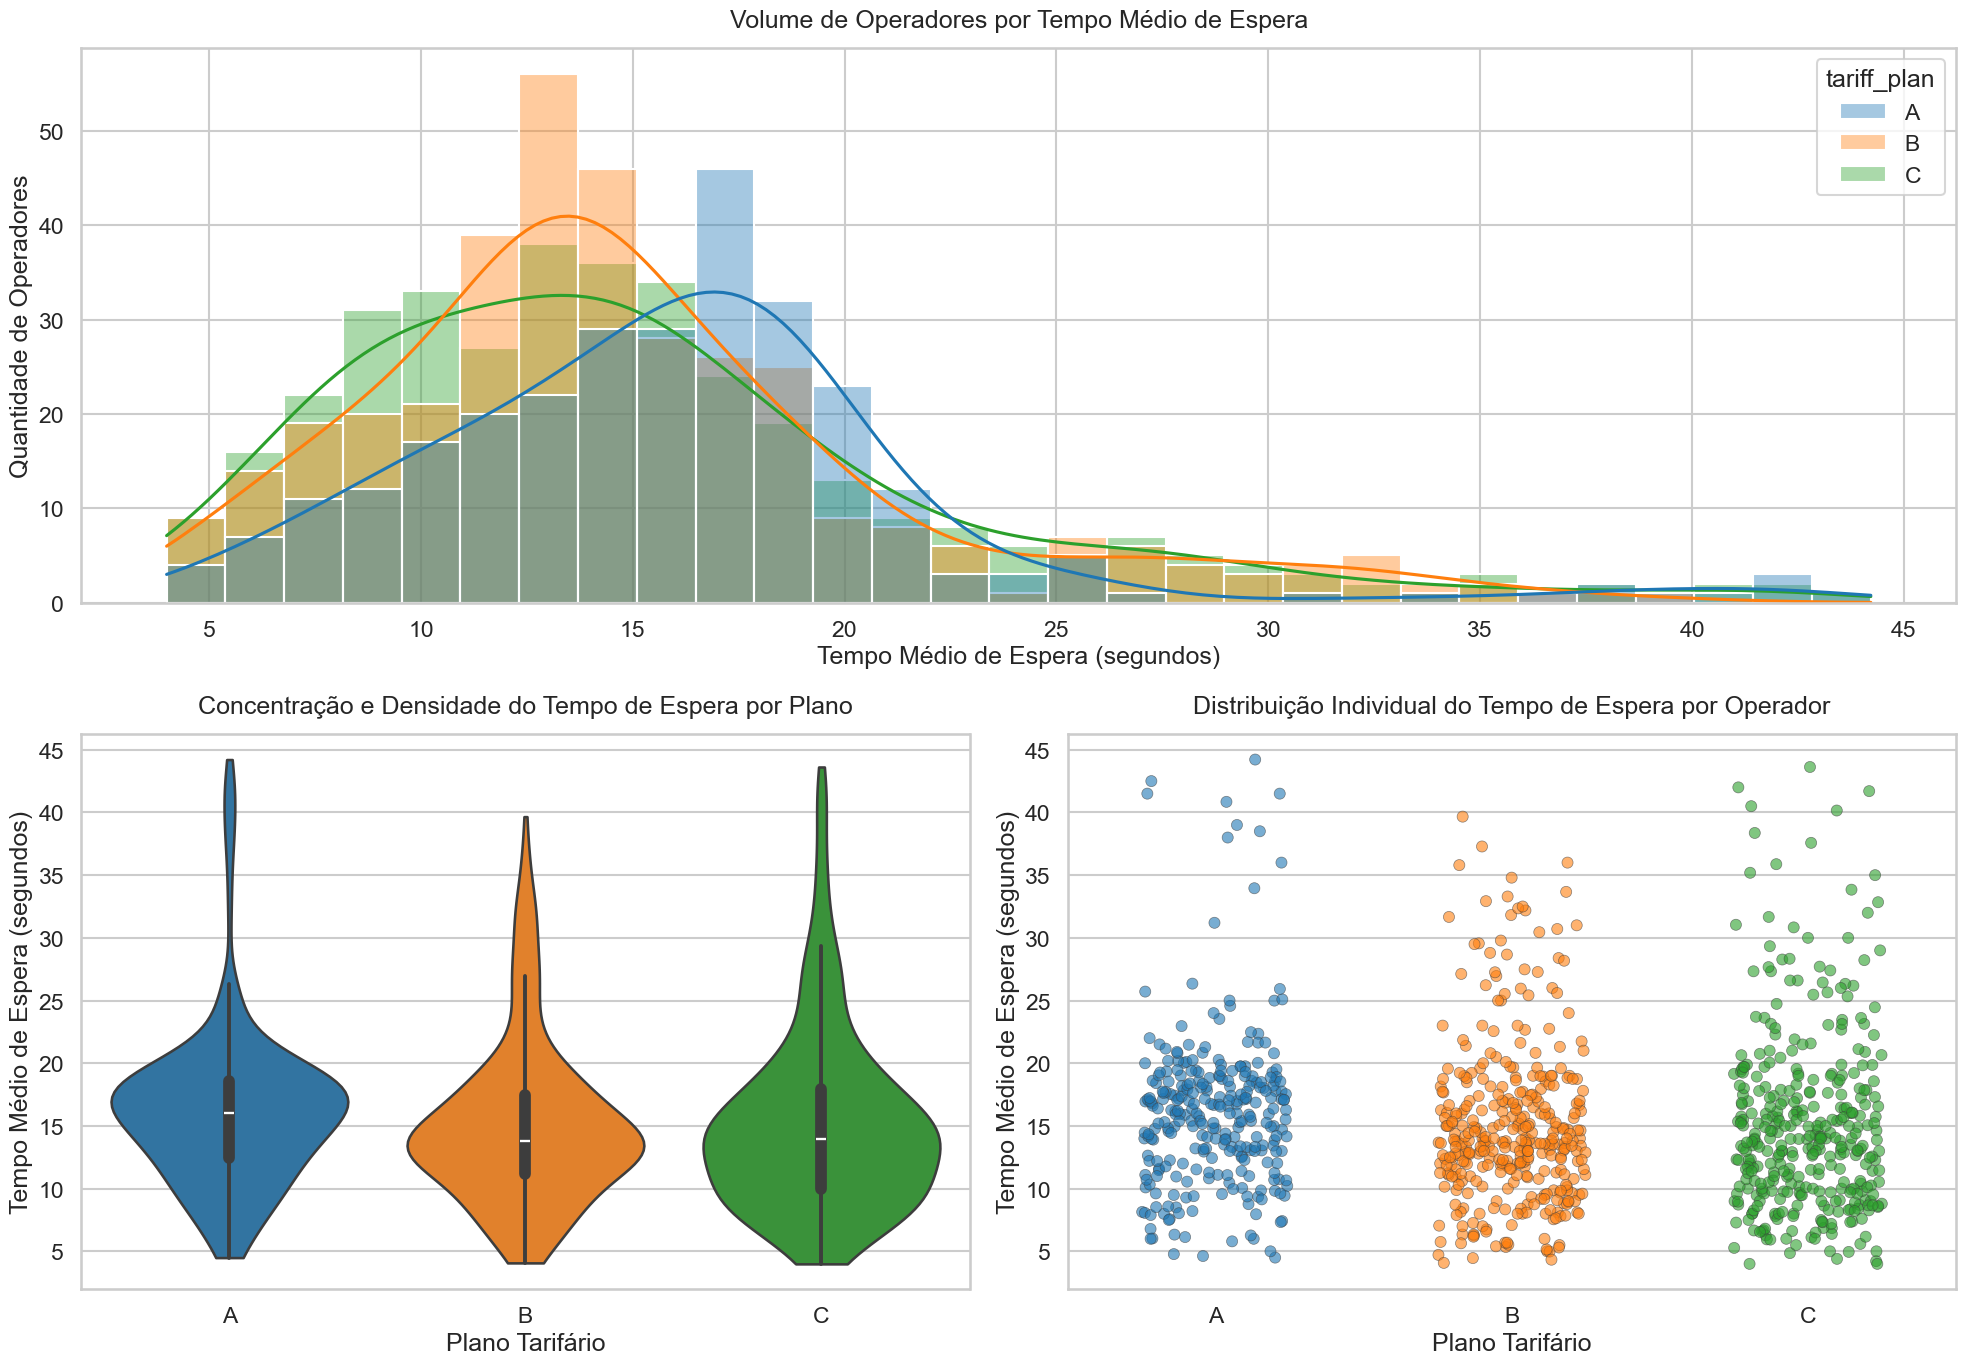

In [42]:
espera = espera.dropna()

sns.set_theme(style="whitegrid", context="talk")

mosaic = [["Hist", "Hist"], ["Violin", "Strip"]]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(20, 14))

sns.histplot(
    data=espera,
    x="espera_media",
    hue="tariff_plan",
    stat="count",
    multiple="layer",
    element="bars",
    kde=True,
    alpha=0.4,
    ax=axes["Hist"],
    palette="tab10",
)
axes["Hist"].set_title(
    "Volume de Operadores por Tempo Médio de Espera", pad=15
)
axes["Hist"].set_xlabel("Tempo Médio de Espera (segundos)")
axes["Hist"].set_ylabel("Quantidade de Operadores")

sns.violinplot(
    data=espera,
    x="tariff_plan",
    y="espera_media",
    ax=axes["Violin"],
    palette="tab10",
    inner="box",
    cut=0,
)
axes["Violin"].set_title(
    "Concentração e Densidade do Tempo de Espera por Plano", pad=15
)
axes["Violin"].set_xlabel("Plano Tarifário")
axes["Violin"].set_ylabel("Tempo Médio de Espera (segundos)")

sns.stripplot(
    data=espera,
    x="tariff_plan",
    y="espera_media",
    ax=axes["Strip"],
    palette="tab10",
    jitter=0.25,
    size=8,
    alpha=0.6,
    linewidth=0.5,
)
axes["Strip"].set_title(
    "Distribuição Individual do Tempo de Espera por Operador", pad=15
)
axes["Strip"].set_xlabel("Plano Tarifário")
axes["Strip"].set_ylabel("Tempo Médio de Espera (segundos)")

plt.tight_layout()
plt.show()

In [43]:
espera.groupby('tariff_plan')['espera_media'].agg(['mean','median','std']).T

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\1810806862.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  espera.groupby('tariff_plan')['espera_media'].agg(['mean','median','std']).T


tariff_plan,A,B,C
mean,16.149417,15.029450,15.121996
median,16.000000,13.785408,13.949427
std,6.335359,6.457996,7.214709


conclusões:

- Operadores que atendem clientes dos planos B e C parecem ser igualmente eficientes quanto ao pré requisito tempo médio de espera. Testaremos essa hipótese mais adiante.
- Operadores que atendem clientes dos planos B e C são mais eficientes quanto ao pré requisito tempo médio de espera que os operadores que atendem clientes do plano A

## 2.3. Analisando a distribuição do número de chamadas ativas para operadores de saída por plano.

Chamadas ativas são aquelas em que o operador liga para o cliente — ou seja, chamadas com `direction` == 'out'. São chamadas proativas, onde o operador toma a iniciativa.

**Fórmula:**

***Chamadas Ativas por Dia = Número de Chamadas Realizadas pelo Operador / Número de Dias Trabalhados***

In [44]:
# Filtrando as linhas com chamadas ativas para operadores de saída:

ativas_saida = calls[calls['direction'] == 'out']

# Calculando as chamadas ativas por dia para operadores de saída:
calls_per_day = ativas_saida.groupby(['operator_id','tariff_plan']).agg({'calls_count':'sum','dia':'nunique'}).reset_index().rename(columns={'dia':'dias'})

calls_per_day['chamadas_por_dia'] = calls_per_day['calls_count'] / calls_per_day['dias']

calls_per_day = calls_per_day[['operator_id','tariff_plan','chamadas_por_dia']].dropna()
calls_per_day['chamadas_por_dia'] = calls_per_day['chamadas_por_dia'].astype('int')

calls_per_day.head()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\1635562967.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calls_per_day = ativas_saida.groupby(['operator_id','tariff_plan']).agg({'calls_count':'sum','dia':'nunique'}).reset_index().rename(columns={'dia':'dias'})


,operator_id,tariff_plan,chamadas_por_dia
1,879896.0,B,17
4,879898.0,B,87
7,880020.0,B,5
10,880022.0,B,5
13,880026.0,B,28


- Analisando os outliers das chamadas por dia:

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\2067151891.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for plano, grupo in calls_per_day.groupby("tariff_plan"):


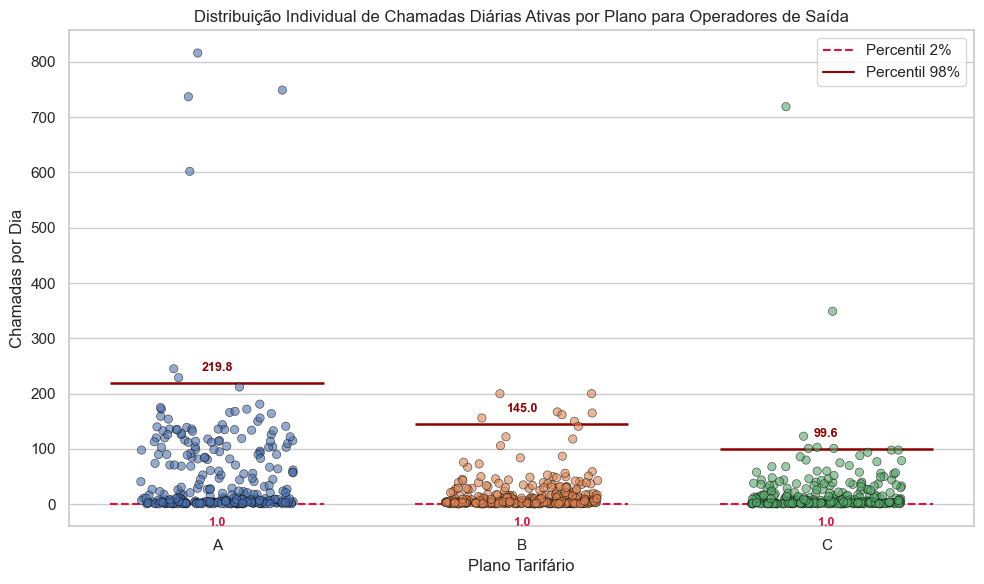

In [45]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=calls_per_day,
    x="tariff_plan",
    y="chamadas_por_dia",
    hue="tariff_plan",
    jitter=0.25,
    size=6,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.5,
)

planos = sorted(calls_per_day["tariff_plan"].unique())
posicoes_x = {plano: i for i, plano in enumerate(planos)}
largura_linha = 0.35
v_max = calls_per_day["chamadas_por_dia"].max()

for plano, grupo in calls_per_day.groupby("tariff_plan"):
    x_pos = posicoes_x[plano]

    p2 = grupo["chamadas_por_dia"].quantile(0.02)
    p98 = grupo["chamadas_por_dia"].quantile(0.98)

    x_min = x_pos - largura_linha
    x_max = x_pos + largura_linha

    plt.hlines(
        y=p2,
        xmin=x_min,
        xmax=x_max,
        colors="crimson",
        linestyles="--",
        linewidth=1.5,
    )
    plt.text(
        x=x_pos,
        y=p2 - (v_max * 0.03),
        s=f"{p2:.1f}",
        color="crimson",
        weight="bold",
        fontsize=9,
        ha="center",
        va="top",
    )

    plt.hlines(
        y=p98,
        xmin=x_min,
        xmax=x_max,
        colors="darkred",
        linestyles="-",
        linewidth=1.8,
    )
    plt.text(
        x=x_pos,
        y=p98 + (v_max * 0.02),
        s=f"{p98:.1f}",
        color="darkred",
        weight="bold",
        fontsize=9,
        ha="center",
        va="bottom",
    )

legend_elements = [
    Line2D([0], [0], color="crimson", linestyle="--", label="Percentil 2%"),
    Line2D([0], [0], color="darkred", linestyle="-", label="Percentil 98%"),
]
plt.legend(handles=legend_elements, loc="upper right")

plt.title("Distribuição Individual de Chamadas Diárias Ativas por Plano para Operadores de Saída")
plt.xlabel("Plano Tarifário")
plt.ylabel("Chamadas por Dia")

plt.tight_layout()
plt.show()

Vamos considerar outliers os valores que escapam da faixa dos percentis 2% e 98% em cada plano. Vamos descarta-los do nosso conjunto de dados.

- Limpando os outliers:

In [46]:
percentis = {} # Criando um dicionário vazio onde a chave será o plano e os valores será a lista [p2, p98] de cada plano

for i, plan in enumerate(order):
    sub_data = calls_per_day[calls_per_day["tariff_plan"] == plan]["chamadas_por_dia"]

    if not sub_data.empty:
        p2 = np.percentile(sub_data, 2)
        p98 = np.percentile(sub_data, 98)
        percentis[plan] = [p2, p98]

percentis

{'A': [np.float64(1.0), np.float64(219.81999999999965)],
 'B': [np.float64(1.0), np.float64(144.95999999999998)],
 'C': [np.float64(1.0), np.float64(99.55999999999995)]}

In [47]:
# limpando os outlaiers em cada plano:
for plan, value in percentis.items():
    filtro = calls_per_day[calls_per_day["tariff_plan"] == plan]
    mask = (filtro["chamadas_por_dia"] > value[0]) & (filtro["chamadas_por_dia"] < value[1])
    calls_per_day[calls_per_day["tariff_plan"] == plan] = filtro[mask]

- Visualizando a Distribuição dos dados limpos:

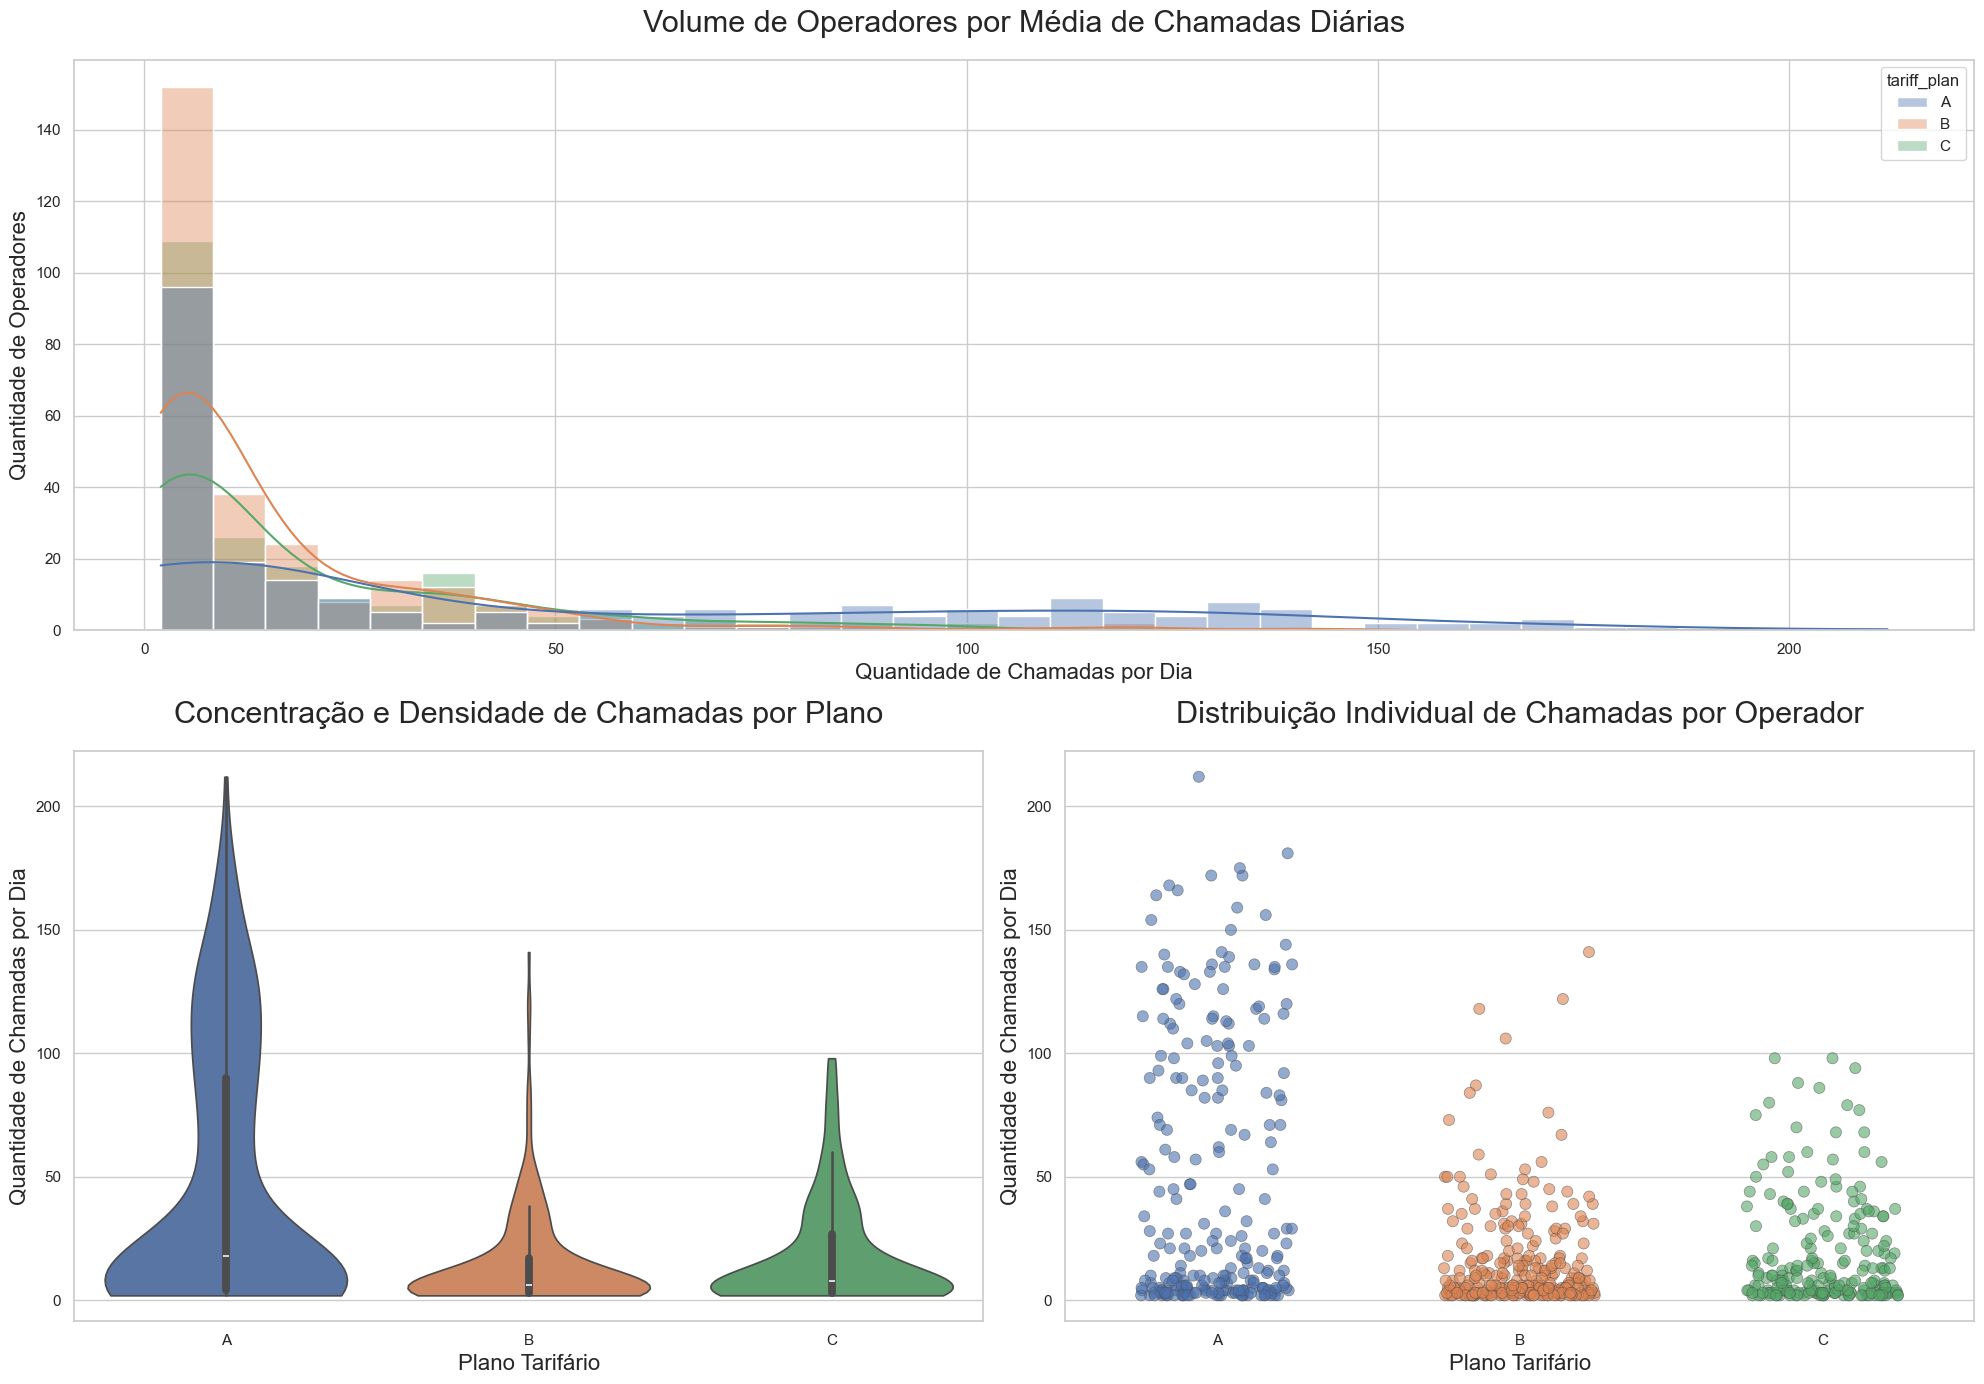

In [48]:
calls_per_day = calls_per_day.dropna()

sns.set_theme(style="whitegrid", context="notebook")

mosaic = [["Hist", "Hist"], ["Violin", "Strip"]]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(20, 14))

sns.histplot(
    data=calls_per_day,
    x="chamadas_por_dia",
    hue="tariff_plan",
    stat="count",
    multiple="layer",
    element="bars",
    kde=True,
    alpha=0.4,
    ax=axes["Hist"],
)
axes["Hist"].set_title(
    "Volume de Operadores por Média de Chamadas Diárias", pad=20, fontsize=22
)
axes["Hist"].set_xlabel("Quantidade de Chamadas por Dia", fontsize=16)
axes["Hist"].set_ylabel("Quantidade de Operadores", fontsize=16)

sns.violinplot(
    data=calls_per_day,
    x="tariff_plan",
    y="chamadas_por_dia",
    hue="tariff_plan",
    ax=axes["Violin"],
    inner="box",
    cut=0,
)
axes["Violin"].set_title(
    "Concentração e Densidade de Chamadas por Plano", pad=20, fontsize=22
)
axes["Violin"].set_xlabel("Plano Tarifário", fontsize=16)
axes["Violin"].set_ylabel("Quantidade de Chamadas por Dia", fontsize=16)

sns.stripplot(
    data=calls_per_day,
    x="tariff_plan",
    y="chamadas_por_dia",
    hue="tariff_plan",
    ax=axes["Strip"],
    jitter=0.25,
    size=8,
    alpha=0.6,
    linewidth=0.5,
)
axes["Strip"].set_title(
    "Distribuição Individual de Chamadas por Operador", pad=20, fontsize=22
)
axes["Strip"].set_xlabel("Plano Tarifário", fontsize=16)
axes["Strip"].set_ylabel("Quantidade de Chamadas por Dia", fontsize=16)

plt.tight_layout()
plt.show()

In [49]:
calls_per_day.groupby('tariff_plan')['chamadas_por_dia'].agg(['mean','median','std']).T

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\1710333123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calls_per_day.groupby('tariff_plan')['chamadas_por_dia'].agg(['mean','median','std']).T


tariff_plan,A,B,C
mean,47.158333,15.065934,18.386047
median,18.000000,6.000000,8.000000
std,53.227544,20.474232,21.694669


conclusões:

- Nenhuma distribuição é normal
- Operadores que atendem clientes do plano A são mais eficientes quanto ao número de chamadas diárias ativas para operadores de saída. A mediana de chamadas ativas é a maior dentre os 3 planos.


## 2.4. Analisando a produtividade geral dos operadores por plano.

**Fórmula:**

Temos 3 critérios com limiares que definem cada operador ineficiente:

Taxa de chamadas perdidas > 15%

Tempo médio de espera > 46 segundos

Chamadas ativas por dia < 50 (apenas operadores de saída)

O ***índice de produtividade geral*** consiste em criar um Score de Ineficiência por operador, onde cada critério violado soma 1 ponto:

| Score	| Classificação |
|-------|---------------|
|   0 ou 1	|✅ Eficiente  |
|   2 ou 3	|🔴 Ineficiente  |

In [50]:
produtividade = calls_per_day.merge(
    espera, 
    on=['operator_id','tariff_plan']
).merge(
    chamadas_perdidas, 
    on=['operator_id','tariff_plan']
)
produtividade = produtividade.dropna()
produtividade.head()

,operator_id,tariff_plan,chamadas_por_dia,espera_media,chamadas_perdidas_percent
0,879896.0,B,17.0,9.628866,26.99
1,879898.0,B,87.0,10.936187,32.28
2,880020.0,B,5.0,6.260870,48.89
3,880022.0,B,5.0,7.260870,53.30
4,880026.0,B,28.0,6.340278,29.03


In [51]:
operadores_unicos = produtividade['operator_id'].nunique()
print(f'Após tratar todos os valores extremos e aplicar todos os filtros necessários, restaram {operadores_unicos} operadores para analisarmos a sua eficiência geral.')

Após tratar todos os valores extremos e aplicar todos os filtros necessários, restaram 681 operadores para analisarmos a sua eficiência geral.


- Criando o índice de produtividade geral de cada operador:

In [52]:
# Analisando cada coluna conforme o seu critério (0 para meta batida, e 1 para meta não batida):
produtividade['chamadas_por_dia_ok'] = produtividade.apply(
    lambda x: 1 if (x['chamadas_por_dia'] < 50) else 0, axis=1
)

produtividade['espera_media_ok'] = produtividade.apply(
    lambda x: 1 if (x['espera_media'] > 46) else 0, axis=1
)

produtividade['chamadas_perdidas_percent_ok'] = produtividade.apply(
    lambda x: 1 if (x['chamadas_perdidas_percent'] > 15) else 0, axis=1
)

In [53]:
# Criando as colunas da produtividade geral e de status do operador:
produtividade['produtividade_geral'] = produtividade['chamadas_por_dia_ok'] + produtividade['espera_media_ok'] + produtividade['chamadas_perdidas_percent_ok']

produtividade.drop(columns=['chamadas_por_dia_ok','espera_media_ok','chamadas_perdidas_percent_ok'], inplace=True)

produtividade['status'] = produtividade.apply(
    lambda x: 'eficiente' if (x['produtividade_geral'] <= 1) else 'ineficiente', axis=1
)

produtividade.head()

,operator_id,tariff_plan,chamadas_por_dia,espera_media,chamadas_perdidas_percent,produtividade_geral,status
0,879896.0,B,17.0,9.628866,26.99,2,ineficiente
1,879898.0,B,87.0,10.936187,32.28,1,eficiente
2,880020.0,B,5.0,6.260870,48.89,2,ineficiente
3,880022.0,B,5.0,7.260870,53.30,2,ineficiente
4,880026.0,B,28.0,6.340278,29.03,2,ineficiente


- Analisando quantos operadores eficientes e ineficientes existem por plano ao longo do tempo:

In [54]:
operators_per_time = calls.merge(
    produtividade,
    on = ['operator_id','tariff_plan']
)

operators_per_time = operators_per_time.dropna()

operators_per_time_copy = operators_per_time.copy() # Vamos precisar disso mais à frente

operators_per_time = operators_per_time[['operator_id'
        , 'dia', 'tariff_plan', 'chamadas_por_dia',
       'espera_media', 'chamadas_perdidas_percent', 'produtividade_geral',
       'status']]

operators_per_time.head()

,operator_id,dia,tariff_plan,chamadas_por_dia,espera_media,chamadas_perdidas_percent,produtividade_geral,status
0,880022.0,2019-08-05,B,5.0,7.26087,53.30,2,ineficiente
1,880020.0,2019-08-05,B,5.0,6.26087,48.89,2,ineficiente
2,880020.0,2019-08-05,B,5.0,6.26087,48.89,2,ineficiente
3,880022.0,2019-08-05,B,5.0,7.26087,53.30,2,ineficiente
4,880020.0,2019-08-05,B,5.0,6.26087,48.89,2,ineficiente


In [55]:
# Calculando a quantidade de operadores eficientes e ineficientes para cada dia e plano:
operadores_por_dia_e_plano = (
    operators_per_time.groupby(["dia", "tariff_plan", "status"])["operator_id"]
    .nunique()
    .reset_index(name="quantidade")
)  

# Ordenando por dia para garantir que o acumulado faça sentido cronológico
operadores_por_dia_e_plano = operadores_por_dia_e_plano.sort_values(by="dia")

# Calculando a quantidade de operadores eficientes e ineficientes acumnulados por dia e plano:
operadores_por_dia_e_plano["quantidade_acumulada"] = (
    operadores_por_dia_e_plano.groupby(["tariff_plan", "status"])[
        "quantidade"
    ].cumsum()
)

operadores_por_dia_e_plano.head()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\42647802.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  operators_per_time.groupby(["dia", "tariff_plan", "status"])["operator_id"]
C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_22308\42647802.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  operadores_por_dia_e_plano.groupby(["tariff_plan", "status"])[


,dia,tariff_plan,status,quantidade,quantidade_acumulada
0,2019-08-02,A,eficiente,0,0
1,2019-08-02,A,ineficiente,0,0
2,2019-08-02,B,eficiente,1,1
3,2019-08-02,B,ineficiente,2,2
4,2019-08-02,C,eficiente,0,0


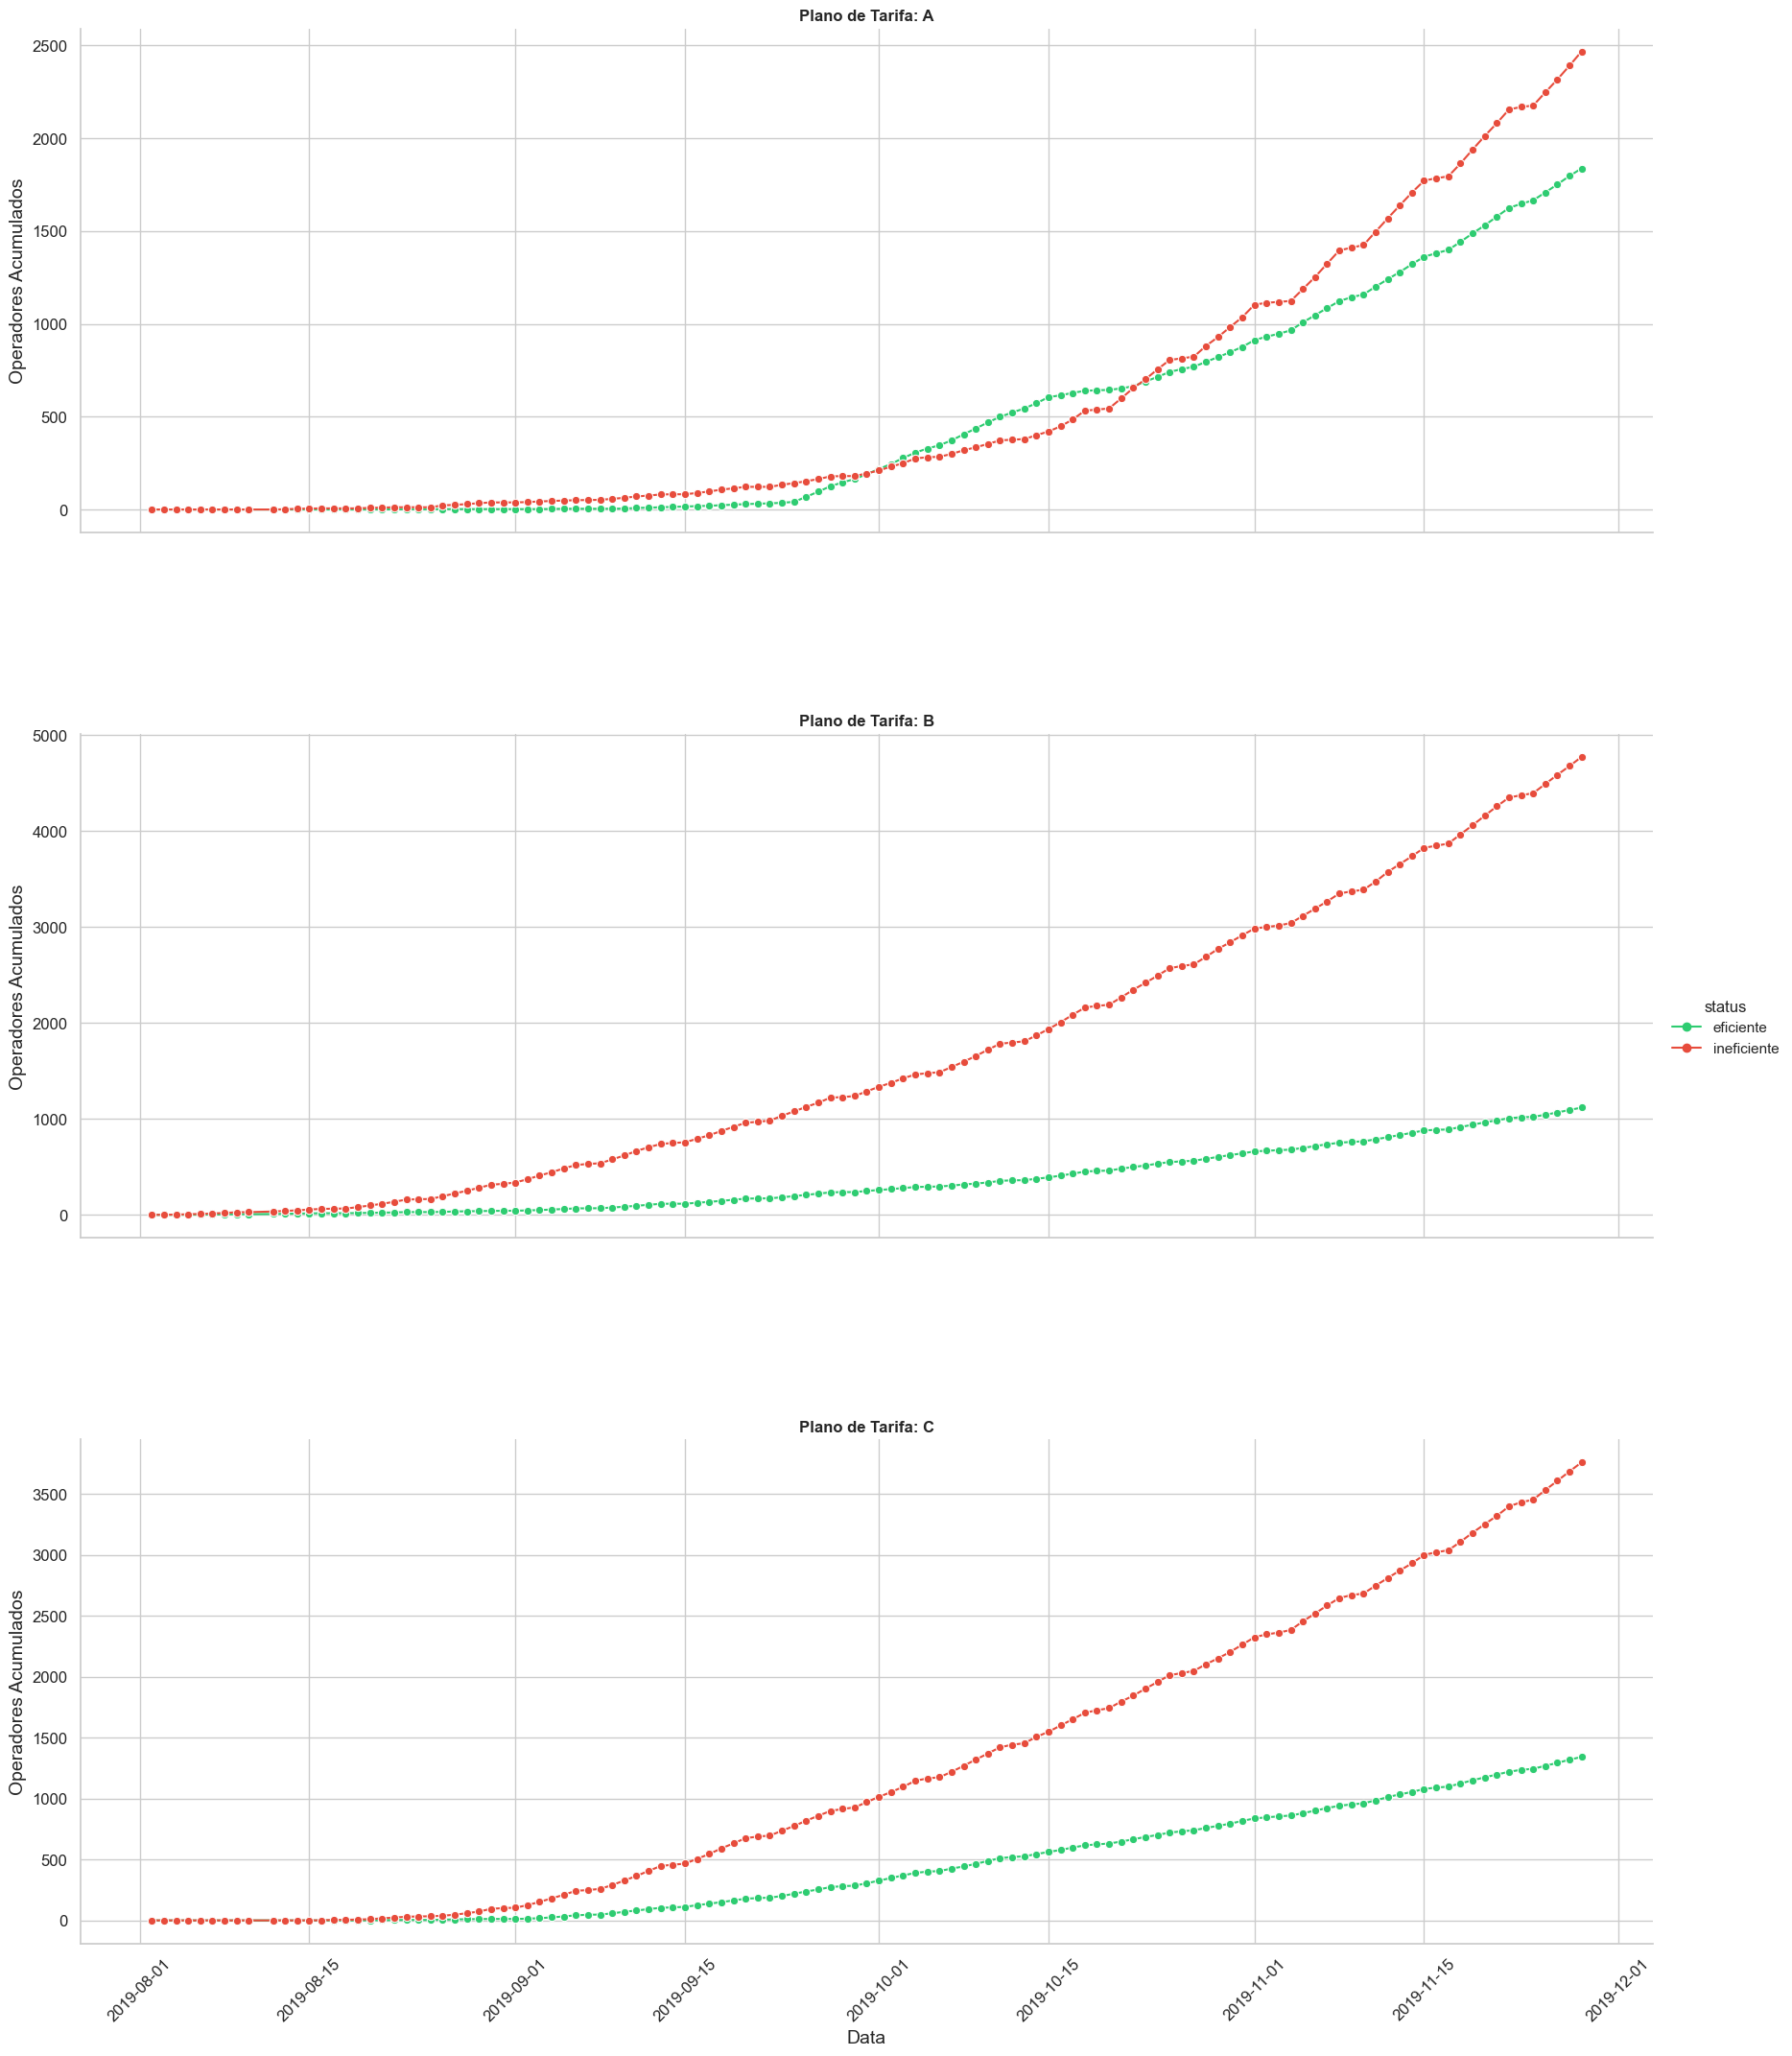

In [56]:
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=operadores_por_dia_e_plano,
    x="dia",
    y="quantidade_acumulada",
    hue="status",
    col="tariff_plan",
    kind="line",
    marker="o",
    palette={"eficiente": "#2ecc71", "ineficiente": "#e74c3c"},
    facet_kws={"sharey": False},
    
    col_wrap=1,  
    height=7,  
    aspect=2.5,  
)


g.set_titles("Plano de Tarifa: {col_name}", fontsize=16, fontweight="bold")
g.set_axis_labels("Data", "Operadores Acumulados", fontsize=14)


for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=45, labelsize=12)
    ax.tick_params(axis="y", labelsize=12)


plt.subplots_adjust(hspace=0.4)

plt.show()

conclusão:

Fica nítido que os operadores do plano A são bem mais eficientes no contexto geral (a distância entre a quantidade de operadores eficientes e não eficientes é a menor dentre os 3 planos)

## 2.5. Listando todos os operadores eficientes e ineficientes totais para cada plano, com base no índice de produtividade geral.

In [57]:
eficientes = produtividade[(produtividade['produtividade_geral'] <= 1)]
ineficientes = produtividade[(produtividade['produtividade_geral'] >= 2)]

eficientes_A = eficientes.loc[(eficientes['tariff_plan'] == 'A'),'operator_id'].to_list()
eficientes_B = eficientes.loc[(eficientes['tariff_plan'] == 'B'),'operator_id'].to_list()
eficientes_C = eficientes.loc[(eficientes['tariff_plan'] == 'C'),'operator_id'].to_list()

ineficientes_A = ineficientes.loc[(ineficientes['tariff_plan'] == 'A'),'operator_id'].to_list()
ineficientes_B = ineficientes.loc[(ineficientes['tariff_plan'] == 'B'),'operator_id'].to_list()
ineficientes_C = ineficientes.loc[(ineficientes['tariff_plan'] == 'C'),'operator_id'].to_list()

In [58]:
print('__________________________________ Operadores EFICIENTES: ______________________________________________')
print(f'Plano A: \n{eficientes_A} \n\nPlano B: \n{eficientes_B} \n\nPlano C: \n{eficientes_C} \n\n')
print('__________________________________ Operadores INEFICIENTES: ____________________________________________')
print(f'Plano A: \n{ineficientes_A} \n\nPlano B: \n{ineficientes_B} \n\nPlano C: \n{ineficientes_C} \n\n')

__________________________________ Operadores EFICIENTES: ______________________________________________
Plano A: 
[891908.0, 906404.0, 906408.0, 908958.0, 908960.0, 914426.0, 915958.0, 918436.0, 919162.0, 919188.0, 919192.0, 919194.0, 919196.0, 919198.0, 919200.0, 919202.0, 919302.0, 919306.0, 919310.0, 919314.0, 919318.0, 919362.0, 919370.0, 919372.0, 919374.0, 919376.0, 919378.0, 919382.0, 919390.0, 919456.0, 919464.0, 919476.0, 919482.0, 919490.0, 919504.0, 919906.0, 920414.0, 920416.0, 921574.0, 921584.0, 921592.0, 921594.0, 921596.0, 922114.0, 922710.0, 923666.0, 924928.0, 928518.0, 929884.0, 934426.0, 937752.0, 937860.0, 940432.0, 940440.0, 940596.0, 940616.0, 940624.0, 940634.0, 940652.0, 940658.0, 945278.0, 945280.0, 945282.0, 945284.0, 945288.0, 945290.0, 945294.0, 945296.0, 945298.0, 945302.0, 945304.0, 945308.0, 945310.0, 945312.0, 945314.0, 945316.0, 945318.0, 945320.0, 945322.0, 945324.0, 947592.0, 947614.0, 947616.0, 947618.0, 947620.0, 947638.0, 947642.0, 947646.0, 9476

## 2.6. Análise de Cohorts semanais: Verificando se operadores que atendem clientes mais antigos são mais eficientes que operadores que atendem clientes mais atuais, com base na média do seu score de produtividade geral.

In [59]:
operators_and_users = operators_per_time_copy[['user_id', 'date_start', 'date','dia', 'operator_id', 'tariff_plan', 'produtividade_geral', 'status', 'chamadas_por_dia',
       'espera_media', 'chamadas_perdidas_percent']]
    

operators_and_users.head()

,user_id,date_start,date,dia,operator_id,tariff_plan,produtividade_geral,status,chamadas_por_dia,espera_media,chamadas_perdidas_percent
0,166377,2019-08-01,2019-08-05 00:00:00+03:00,2019-08-05,880022.0,B,2,ineficiente,5.0,7.26087,53.30
1,166377,2019-08-01,2019-08-05 00:00:00+03:00,2019-08-05,880020.0,B,2,ineficiente,5.0,6.26087,48.89
2,166377,2019-08-01,2019-08-05 00:00:00+03:00,2019-08-05,880020.0,B,2,ineficiente,5.0,6.26087,48.89
3,166377,2019-08-01,2019-08-05 00:00:00+03:00,2019-08-05,880022.0,B,2,ineficiente,5.0,7.26087,53.30
4,166377,2019-08-01,2019-08-05 00:00:00+03:00,2019-08-05,880020.0,B,2,ineficiente,5.0,6.26087,48.89


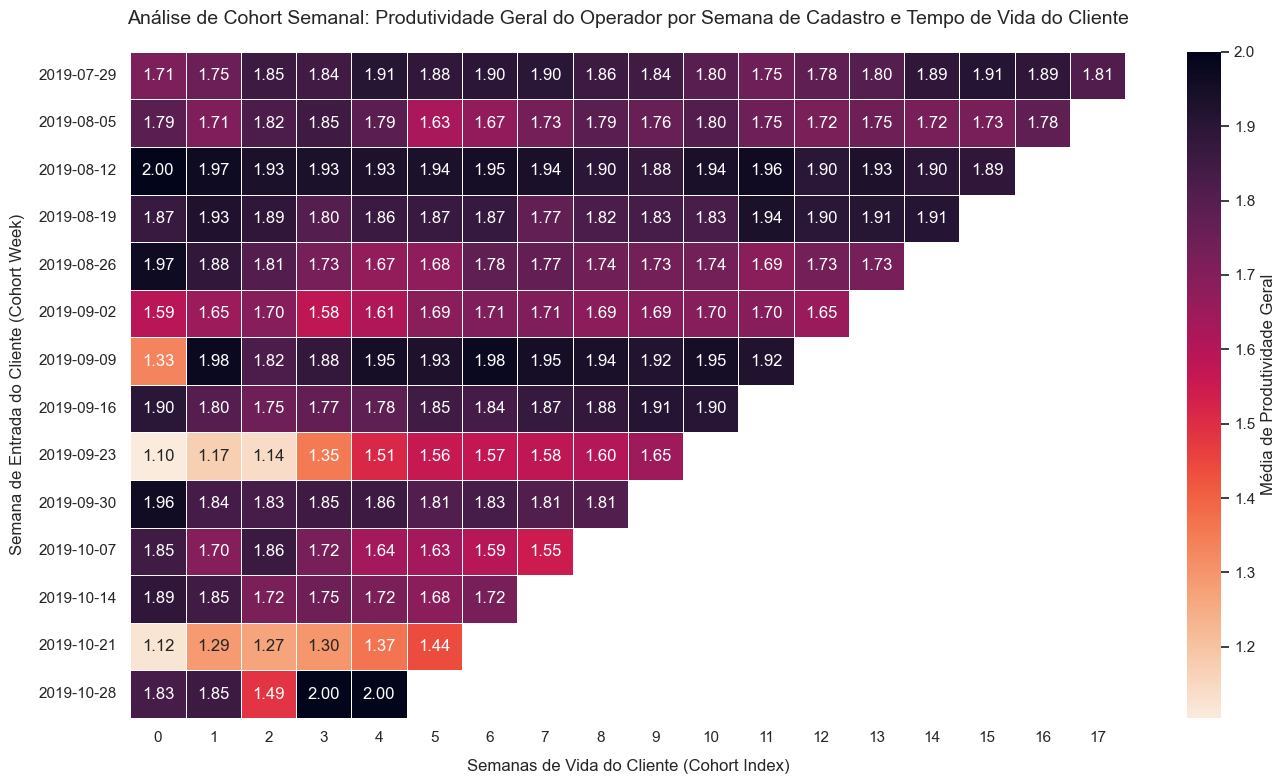

In [60]:
# Calculando as cohorts semanais para a produtividade geral, e imprimindo o heatmap:
operators_and_users = operators_and_users.copy()

operators_and_users["date_start"] = pd.to_datetime(
    operators_and_users["date_start"]
)
operators_and_users["date"] = pd.to_datetime(
    operators_and_users["date"], utc=True
).dt.tz_localize(None)

operators_and_users["cohort_week"] = operators_and_users[
    "date_start"
].dt.to_period("W").dt.start_time
operators_and_users["activity_week"] = operators_and_users[
    "date"
].dt.to_period("W").dt.start_time

operators_and_users["cohort_index"] = (
    (operators_and_users["activity_week"] - operators_and_users["cohort_week"])
    .dt.days
    / 7
).astype(int)

operators_and_users = operators_and_users[
    operators_and_users["cohort_index"] >= 0
].copy()

cohort_data = (
    operators_and_users.groupby(["cohort_week", "cohort_index"])[
        "produtividade_geral"
    ]
    .mean()
    .reset_index()
)
cohort_matrix = cohort_data.pivot(
    index="cohort_week", columns="cohort_index", values="produtividade_geral"
)
cohort_matrix.index = cohort_matrix.index.strftime("%Y-%m-%d")

plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

sns.heatmap(
    cohort_matrix,
    annot=True,
    fmt=".2f",
    cmap="rocket_r",
    linewidths=0.5,
    cbar_kws={"label": "Média de Produtividade Geral"},
)

plt.title(
    "Análise de Cohort Semanal: Produtividade Geral do Operador por Semana de Cadastro e Tempo de Vida do Cliente",
    fontsize=14,
    pad=20,
)
plt.xlabel("Semanas de Vida do Cliente (Cohort Index)", fontsize=12, labelpad=10)
plt.ylabel(
    "Semana de Entrada do Cliente (Cohort Week)", fontsize=12, labelpad=10
)

plt.tight_layout()
plt.show()

conclusão:

- No geral, Os operadores que atendem clientes mais antigos não são necessariamente mais eficientes do que os que atendem clientes mais atuais. A hipótese levantada no enunciado não se confirma de forma consistente. Não há nenhum padrão no gráfico que nos confirma isso.

- Porém, as cohorts dos usuários que se cadastraram em '2019-09-23' e em '2019-10-21' apresentam operadores significativamente mais eficientes.

# 3. Testes de Hipóteses:

**Vamos testar como os operadores eficientes e ineficientes, categorizados conforme o score de produtividade geral, se comportam em cada uma das outras métricas - KPIs 1, 2 e 3**

Para todos os testes, vamos testar igualdades entre médias de dados contínuos

Separando a produtividade de operadores eficientes e ineficientes para os testes de hipótese a seguir:

In [61]:
eficientes_test = produtividade[produtividade['status'] == 'eficiente']

eficientes_test.head(3)

,operator_id,tariff_plan,chamadas_por_dia,espera_media,chamadas_perdidas_percent,produtividade_geral,status
1,879898.0,B,87.0,10.936187,32.28,1,eficiente
10,882690.0,B,67.0,21.390179,29.47,1,eficiente
17,884478.0,B,59.0,12.459982,50.39,1,eficiente


In [62]:
ineficientes_test = produtividade[produtividade['status'] == 'ineficiente']

ineficientes_test.head(3)

,operator_id,tariff_plan,chamadas_por_dia,espera_media,chamadas_perdidas_percent,produtividade_geral,status
0,879896.0,B,17.0,9.628866,26.99,2,ineficiente
2,880020.0,B,5.0,6.260870,48.89,2,ineficiente
3,880022.0,B,5.0,7.260870,53.30,2,ineficiente


## 3.1.  Será que operadores classificados como ineficientes (Scores 2 e 3) têm taxa de chamada perdida significativamente maior que os eficientes (Score 0 ou 1)?

In [63]:
eficientes_chamadas_perdidas = eficientes_test['chamadas_perdidas_percent']
ineficientes_chamadas_perdidas = ineficientes_test['chamadas_perdidas_percent']

print(f'Média das taxas de chamadas perdidas dos operadores EFICIENTES: {round(eficientes_chamadas_perdidas.mean(),2)}%')
print(f'\nMédia das taxas de chamadas perdidas dos operadores INEFICIENTES: {round(ineficientes_chamadas_perdidas.mean(),2)}%\n')

Média das taxas de chamadas perdidas dos operadores EFICIENTES: 33.94%

Média das taxas de chamadas perdidas dos operadores INEFICIENTES: 36.26%



Operadores INEFICIENTES parecem ter taxa de chamadas perdidas maior que os operadores EFICIENTES. Vamos verificar essa hipótese:


- ***Hipótese Nula:*** Não há diferença significativa entre as taxa de chamadas perdidas dos Operadores INEFICIENTES e EFICIENTES.
- ***Hipótese Alternativa:*** Operadores INEFICIENTES tem taxa de chamadas perdidas significativamente diferente dos operadores EFICIENTES.


In [64]:
h_0 = 'Não há diferença significativa entre as taxa de chamadas perdidas dos Operadores INEFICIENTES e EFICIENTES.'
h_1 = 'Operadores INEFICIENTES tem taxa de chamadas perdidas significativamente diferente dos operadores EFICIENTES.'
significancia = 0.05

In [65]:
teste_dados_continuos(eficientes_chamadas_perdidas, ineficientes_chamadas_perdidas, h_0, h_1, significancia)

Shapiro-Wilk (Grupo A): p=0.00000 | Normal: False
Shapiro-Wilk (Grupo B): p=0.00000 | Normal: False
Decisão: Usando Mann-Whitney

--- Resultado do Teste de Hipótese ---
P-valor: 0.2696 | Alpha: 0.05
✅ Mantemos H0: Não há diferença significativa entre as taxa de chamadas perdidas dos Operadores INEFICIENTES e EFICIENTES.


conclusão:

Com uma certeza estatistica de 95% (nível de significância de 5%), constatamos que: Não há diferença significativa entre as taxa de chamadas perdidas dos Operadores INEFICIENTES e EFICIENTES.

## 3.2.  Será que operadores classificados como ineficientes (Scores 2 e 3) têm tempo de espera significativamente maior que os eficientes (Score 0 ou 1)?

In [66]:
eficientes_espera = eficientes_test['espera_media']
ineficientes_espera = ineficientes_test['espera_media']

print(f'Tempo de espera médio de chamadas dos operadores EFICIENTES: {round(eficientes_espera.mean(),2)}s')
print(f'\nTempo de espera médio de chamadas dos operadores INEFICIENTES: {round(ineficientes_espera.mean(),2)}s\n')

Tempo de espera médio de chamadas dos operadores EFICIENTES: 15.98s

Tempo de espera médio de chamadas dos operadores INEFICIENTES: 13.66s



Operadores INEFICIENTES parecem ter tempo de espera menor que os operadores EFICIENTES. Vamos verificar essa hipótese:

- ***Hipótese Nula:*** Não há diferença significativa entre tempo de espera médio das chamadas dos Operadores INEFICIENTES e EFICIENTES.
- ***Hipótese Alternativa:*** Operadores INEFICIENTES tem tempo de espera médio de chamadas significativamente diferente dos operadores EFICIENTES.

In [67]:
h_0 = 'Não há diferença significativa entre tempo de espera médio das chamadas dos Operadores INEFICIENTES e EFICIENTES.'
h_1 = 'Operadores INEFICIENTES tem tempo de espera médio de chamadas significativamente diferente dos operadores EFICIENTES.'
significancia = 0.01

In [68]:
teste_dados_continuos(eficientes_espera, ineficientes_espera, h_0, h_1, significancia)

Shapiro-Wilk (Grupo A): p=0.00000 | Normal: False
Shapiro-Wilk (Grupo B): p=0.00000 | Normal: False
Decisão: Usando Mann-Whitney

--- Resultado do Teste de Hipótese ---
P-valor: 0.0000 | Alpha: 0.01
❌ Rejeitamos H0: Operadores INEFICIENTES tem tempo de espera médio de chamadas significativamente diferente dos operadores EFICIENTES.


conclusão:

Com uma certeza estatistica de 99% (nível de significância de 1%), constatamos que: Operadores INEFICIENTES tem tempo de espera médio de chamadas significativamente menor que operadores EFICIENTES.

## 3.3.  Será que operadores classificados como ineficientes (Scores 2 e 3) têm Volume de Chamadas Ativas para Operadores de Saída significativamente menor que os eficientes (Score 0 ou 1)?

In [69]:
eficientes_chamadas_ativas = eficientes_test['chamadas_por_dia']
ineficientes_chamadas_ativas = ineficientes_test['chamadas_por_dia']

print(f'O volume médio de chamadas ativas diárias dos operadores EFICIENTES é: {int(eficientes_chamadas_ativas.mean())} chamadas diárias ativas')
print(f'\nO volume médio de chamadas ativas diárias dos operadores INEFICIENTES é: {int(ineficientes_chamadas_ativas.mean())} chamadas diárias ativas\n')

O volume médio de chamadas ativas diárias dos operadores EFICIENTES é: 67 chamadas diárias ativas

O volume médio de chamadas ativas diárias dos operadores INEFICIENTES é: 12 chamadas diárias ativas



Operadores INEFICIENTES parecem ter bem menos chamadas diárias ativas que os operadores EFICIENTES. Vamos verificar essa hipótese:

- ***Hipótese Nula:*** Não há diferença significativa entre o número de chamadas diárias ativas dos Operadores INEFICIENTES e EFICIENTES.
- ***Hipótese Alternativa:*** Os números de chamadas diárias ativas dos Operadores INEFICIENTES e EFICIENTES são significativamente diferentes.

In [70]:
h_0 = 'Não há diferença significativa entre o número de chamadas diárias ativas dos Operadores INEFICIENTES e EFICIENTES.'
h_1 = 'Os números de chamadas diárias ativas dos Operadores INEFICIENTES e EFICIENTES são significativamente diferentes.'
significancia = 0.01

In [71]:
teste_dados_continuos(eficientes_chamadas_ativas, ineficientes_chamadas_ativas, h_0, h_1, significancia)

Shapiro-Wilk (Grupo A): p=0.00000 | Normal: False
Shapiro-Wilk (Grupo B): p=0.00000 | Normal: False
Decisão: Usando Mann-Whitney

--- Resultado do Teste de Hipótese ---
P-valor: 0.0000 | Alpha: 0.01
❌ Rejeitamos H0: Os números de chamadas diárias ativas dos Operadores INEFICIENTES e EFICIENTES são significativamente diferentes.


conclusão:

Com uma certeza estatistica de 99% (nível de significância de 1%), constatamos que: Operadores INEFICIENTES tem bem menos chamadas diárias ativas que os operadores EFICIENTES

## 3.4. Será que operadores que atendem clientes dos planos B e C possuem o mesmo tempo médio de espera?

In [72]:
operadores_B = produtividade.loc[produtividade['tariff_plan'] == 'B','espera_media']
operadores_C = produtividade.loc[produtividade['tariff_plan'] == 'C','espera_media']

In [73]:
print(f'Tempo médio de espera dos operadores que atendem clientes do plano B: {int(operadores_B.mean())}s')
print(f'Tempo médio de espera dos operadores que atendem clientes do plano C: {int(operadores_C.mean())}s\n')

Tempo médio de espera dos operadores que atendem clientes do plano B: 14s
Tempo médio de espera dos operadores que atendem clientes do plano C: 12s



- ***Hipótese Nula:*** NÃO HÁ DIFERENÇA significativa entre os tempos médios de espera dos operadores que atendem clientes dos planos B e C.
- ***Hipótese Alternativa:*** Os tempos médios de espera dos operadores que atendem clientes dos planos B e C são significativamente DIFERENTES.

In [74]:
h_0 = 'NÃO HÁ DIFERENÇA significativa entre os tempos médios de espera dos operadores que atendem clientes dos planos B e C.'
h_1 = 'Os tempos médios de espera dos operadores que atendem clientes dos planos B e C são significativamente DIFERENTES.'
significancia = 0.01

In [75]:
teste_dados_continuos(operadores_B, operadores_C, h_0, h_1, significancia)

Shapiro-Wilk (Grupo A): p=0.00000 | Normal: False
Shapiro-Wilk (Grupo B): p=0.00000 | Normal: False
Decisão: Usando Mann-Whitney

--- Resultado do Teste de Hipótese ---
P-valor: 0.0026 | Alpha: 0.01
❌ Rejeitamos H0: Os tempos médios de espera dos operadores que atendem clientes dos planos B e C são significativamente DIFERENTES.


conclusão:

Com uma certeza estatistica de 99% (nível de significância de 1%), constatamos que: Os tempos médios de espera dos operadores que atendem clientes dos planos B e C são significativamente DIFERENTES. Isso quer dizer que os operadores que atendem clientes do plano C são os mais eficientes nesse critério.

# 4. Conclusões Gerais e Recomendações de negócio

## Da Análise Exploratória de dados (EDA) feita:

Na nossa EDA, fizemos as seguintes conclusões:
- ***Sobre as Taxas de chamadas perdidas:*** Operadores que atendem clientes do plano C são mais eficientes nesse critério.
  
- ***Sobre o Tempo médio de espera:*** Operadores que atendem clientes do plano C são também são mais eficientes nesse critério. Os operadores que atendem clientes do plano A são os menos eficientes.

- ***Sobre as Chamadas ativas por dia:*** Operadores do plano A são mais eficientes nesse critério — possuem a maior mediana de chamadas ativas diárias. Nenhuma das distribuições é normal.

- ***Sobre a Produtividade geral ao longo do tempo:*** Operadores do plano A são os mais eficientes no contexto geral — a diferença entre eficientes e ineficientes é a menor dentre os 3 planos.

- ***Sobre a Análise de Cohorts semanais:*** Operadores que atendem clientes mais antigos não são necessariamente mais eficientes — não há padrão consistente. Exceção: cohorts de '2019-09-23' e '2019-10-21' apresentam operadores significativamente mais eficientes.

## Dos testes de Hipótese:

Quando analisamos o comportamento dos operadores eficientes e ineficientes em cada critério métrico em particular, constatamos que:

- Não há diferença significativa entre as taxa de chamadas perdidas dos Operadores INEFICIENTES e EFICIENTES.
- Operadores INEFICIENTES tem tempo de espera médio de chamadas significativamente menor que operadores EFICIENTES.
- Operadores INEFICIENTES tem bem menos chamadas diárias ativas que os operadores EFICIENTES

## Recomendações de negócio: 

- **1. Equalização de Processos por Plano de Cliente (Planos A vs. C)**
     
Ação: Cruzar as melhores práticas dos operadores do Plano C com os do Plano A e criar um comitê de melhoria contínua.

Justificativa: A EDA apontou que os operadores do Plano C dominam a eficiência em chamadas perdidas e tempo de espera, enquanto o Plano A amarga os piores tempos de espera (embora tenha alta produtividade em chamadas ativas). É preciso entender se o script do Plano A é complexo demais, se faltam ferramentas de automação para essa carteira ou se o perfil de cliente exige um transbordo que hoje não existe.

- **2. Implementação de Plano de Capacitação Focado e Gestão de Capacidade (Capacity Planning)**
     
Ação: Desenvolver um programa de shadowing (espelhamento) e reciclagem.

Foco 1: Capacitar os operadores "eficientes" (alta volumetria ativa) com as técnicas de assertividade e agilidade dos operadores "ineficientes" para reduzir o tempo de espera geral.

Foco 2: Entender o gargalo dos operadores "ineficientes" em chamadas ativas. Se eles passam mais tempo ociosos ou se a carteira deles demanda mais pós-atendimento (backoffice), precisamos redistribuir a carga de trabalho.

- **3. Investigação de Anomalias de Desempenho (Deep Dive em Cohorts)**
     
Ação: Realizar uma auditoria operacional e de liderança especificamente nas safras (cohorts) de 23/09/2019 e 21/10/2019.

Justificativa: Sendo as únicas cohorts com operadores significativamente mais eficientes sem um padrão lógico temporal, precisamos isolar a variável que causou isso. Foi um processo de onboarding diferenciado? Uma liderança específica? Um lote de leads com maior propensão ao contato? Identificado o fator de sucesso, ele deve ser padronizado para toda a operação (rollout institucional).

- **4. Alocação Estratégica de Turnos e Rotinas Operacionais**
     
Ação: Adequar as janelas de chamadas ativas dos operadores. Dado que as distribuições de produtividade ao longo do tempo não são normais, a operação sofre com picos e vales de ociosidade/sobrecarga. Recomenda-se a implementação de um software de Workforce Management (WFM) para prever melhor essas curvas e ajustar as escalas.